<a href="https://colab.research.google.com/github/esttefiCarde/analisis-salarios-mineria-datos/blob/main/TerceraEvaluacionEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos para la Predicción de Salarios en el Ámbito Laboral

integrante: Estephany Cárdenas


Asignatura: Mineria de Datos


Sección: 002D

Profesor: Carlos Humberto Munoz Salgado



## Contexto del dataset y objetivo del análisis



El presente análisis se basa en un dataset relacionado con información laboral, el cual contiene variables como tipo de trabajo, años de experiencia, nivel educacional, cantidad de habilidades, certificaciones y salario.

El objetivo principal de este análisis es explorar y comprender la relación entre distintas variables y el salario, identificando los factores que pueden influir en los ingresos de los trabajadores. Para ello, se realiza un análisis exploratorio de datos (EDA), que incluye visualizaciones, estadísticas descriptivas y análisis de correlación.

Adicionalmente, se aplican técnicas de transformación de variables categóricas a formato numérico, con el fin de facilitar su uso en análisis más avanzados y en futuras etapas de modelamiento dentro del contexto de minería de datos.
https://www.kaggle.com/datasets/hosan707/job-salary-prediction-dataset

In [8]:
# Importamos la librería pandas para manipulación y análisis de datos
import pandas as pd
# Importamos matplotlib para la creación de gráficos
import matplotlib.pyplot as plt
# Importamos seaborn para visualizaciones estadísticas más avanzadas
import seaborn as sns


In [9]:
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Ruta del dataset
ruta_dataset = "/content/drive/MyDrive/Mineria de Datos /job_salary.csv"



Mounted at /content/drive


In [10]:
# Cargamos el dataset desde un archivo CSV y lo almacenamos en el dataframe 'df'
df = pd.read_csv(ruta_dataset)

## Exploración inicial del dataset

En esta sección se realiza una exploración inicial del dataset con el objetivo de comprender su estructura, visualizar los primeros registros y conocer la cantidad de datos y variables disponibles.

In [11]:
# Mostramos las primeras filas del dataset para observar su estructura
# y entender cómo están organizadas las variables
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [12]:
df.tail()  #visualizamos las ultimas 5 filas

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467
249999,Data Analyst,16,Diploma,2,Technology,Medium,UK,No,5,133084


In [13]:
# Obtenemos la cantidad de filas y columnas del dataset
filas, columnas = df.shape

print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Cantidad de filas: 250000
Cantidad de columnas: 10


In [14]:
# Mostramos información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


# Revisión de calidad de datos

En esta sección se analizan las variables numéricas del dataset, con el fin de comprender su comportamiento. Además, se revisa la existencia de valores nulos para evaluar la calidad de los datos.

In [15]:
# Revisamos la cantidad de valores nulos en cada columna del dataset
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [16]:
# Calculamos la cantidad total de valores nulos en el dataset
df.isnull().sum().sum()

np.int64(0)

In [17]:
# Mostramos el tipo de dato de cada columna
df.dtypes

,0
job_title,object
experience_years,int64
education_level,object
skills_count,int64
industry,object
company_size,object
location,object
remote_work,object
certifications,int64
salary,int64


In [18]:
# Mostramos los nombres de todas las columnas del dataset
# Esto nos permite identificar las variables disponibles para el análisis
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

### Mapeo de datos

Basado en las características de los datos observadas, cada variable en el dataset se clasifica de la siguiente manera:

| Columna            | Categoría Principal | Subtipo Específico | Descripción y Racionalización                                                                                               |
|:-------------------|:--------------------|:-------------------|:----------------------------------------------------------------------------------------------------------------------------|
| `job_title`        | Categórica          | Nominal            | Representa diferentes títulos de trabajo sin un orden intrínseco.                                                           |
| `experience_years` | Numérica            | Discreta            | Conteo de años de experiencia, toma valores enteros.                                                                        |
| `education_level`  | Categórica          | Ordinal            | Aunque es texto, los niveles educativos tienen una jerarquía clara (e.g., Bachillerato < Maestría < Doctorado).             |
| `skills_count`     | Numérica            | Discreta            | Conteo de habilidades, toma valores enteros.                                                                                |
| `industry`         | Categórica          | Nominal            | Diferentes tipos de industria sin un orden inherente.                                                                       |
| `company_size`     | Categórica          | Ordinal            | El tamaño de la empresa (e.g., 'Small', 'Medium', 'Large') implica una escala con un orden.                                |
| `location`         | Categórica          | Nominal            | Nombres de ubicaciones geográficas, sin un orden natural entre ellas.                                                       |
| `remote_work`      | Categórica          | Nominal (Binaria/Multinomial) | Indica si el trabajo es remoto ('Yes', 'No', 'Hybrid'), las categorías no tienen un orden intrínseco.                   |
| `certifications`   | Numérica            | Discreta            | Conteo de certificaciones, toma valores enteros.                                                                            |
| `salary`           | Numérica            | Continua            | El salario es una medida de cantidad que puede tomar cualquier valor dentro de un rango (aunque aquí se almacene como entero, conceptualmente es continua). |

**Conceptos Clave:**

*   **Categórica:** Representa cualidades o características que se agrupan en categorías.
    *   **Nominal:** Las categorías no tienen un orden intrínseco (ej. `job_title`).
    *   **Ordinal:** Las categorías tienen un orden o jerarquía natural (ej. `education_level`).
*   **Numérica:** Representa cantidades medibles.
    *   **Discreta:** Toman valores enteros específicos (ej. `experience_years`, `skills_count`).
    *   **Continua:** Puede tomar cualquier valor dentro de un rango dado (ej. `salary`).

### Análisis de variables categóricas

In [19]:
# Contamos la frecuencia de cada categoría en la variable 'job_title'
df['job_title'].value_counts()


,count
job_title,
Backend Developer,21125
Cybersecurity Analyst,20959
Product Manager,20950
AI Engineer,20945
Data Scientist,20890
DevOps Engineer,20889
Software Engineer,20876
Data Analyst,20722
Cloud Engineer,20686


In [20]:
# Imprime en pantalla la cantidad de tipos de trabajos distintos (valores únicos)
# que existen en la columna 'job_title' del dataset
print("Cantidad de trabajos distintos:", df['job_title'].nunique())

Cantidad de trabajos distintos: 12


In [21]:
# Contamos la frecuencia de cada nivel educacional
df['education_level'].value_counts()

,count
education_level,
Master,50352
High School,50065
Bachelor,49950
PhD,49857
Diploma,49776


In [22]:
# Imprime en pantalla la cantidad de niveles educacionales distintos (valores únicos)
# presentes en la columna 'education_level' del dataset
print("Cantidad niveles educacionales:", df['education_level'].nunique())

Cantidad niveles educacionales: 5


In [23]:
# Contamos la frecuencia de cada tipo de industria
df['industry'].value_counts()

,count
industry,
Finance,25393
Consulting,25258
Media,25034
Manufacturing,25024
Technology,24903
Government,24901
Healthcare,24898
Education,24889
Telecom,24859


In [24]:
# Imprime en pantalla la cantidad de categorías distintas (valores únicos)
# que existen en la columna 'industry' del dataset
print("Cantidad de industrias:", df['industry'].nunique())

Cantidad de industrias: 10


In [25]:
# Contamos la frecuencia de cada modalidad de trabajo
df['remote_work'].value_counts()

,count
remote_work,
No,83621
Hybrid,83476
Yes,82903


In [26]:
# Imprime en pantalla la cantidad de categorías distintas (valores únicos)
# que existen en la variable 'remote_work', es decir, cuántas modalidades de trabajo hay
print("Cantidad de opciones de trabajo:", df['remote_work'].nunique())

Cantidad de opciones de trabajo: 3


# Estadistica descriptiva de las variables numericas

In [27]:
# Generamos estadísticas descriptivas de las variables numéricas
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


El análisis descriptivo de las variables numéricas permitió observar que el dataset cuenta con 250.000 registros sin valores faltantes. La experiencia laboral presenta un promedio de 10 años, mientras que la cantidad de habilidades también se sitúa en torno a 10. En cuanto a certificaciones, se observa un promedio bajo, cercano a 2.5. Respecto al salario, se evidencia una media de aproximadamente 145.718, con una amplia variabilidad entre los valores mínimos y máximos. Además, el análisis de percentiles muestra que la distribución de los salarios no es uniforme, existiendo diferencias significativas entre los distintos grupos.

In [28]:
# Calculamos la correlación entre variables numéricas para analizar su relación
corr = df[['experience_years', 'skills_count', 'certifications', 'salary']].corr()
corr

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000149,-0.000198,0.437627
skills_count,0.000149,1.000000,-0.002230,0.127300
certifications,-0.000198,-0.002230,1.000000,0.073819
salary,0.437627,0.127300,0.073819,1.000000



Se observa que la variable experiencia presenta una correlación positiva moderada con el salario (0.437), lo que indica que a mayor experiencia laboral, mayor tiende a ser el ingreso.

Por otro lado, variables como la cantidad de habilidades y certificaciones presentan correlaciones positivas débiles con el salario, lo que sugiere que tienen menor influencia en los ingresos

Se observan algunas correlaciones negativas entre variables; sin embargo, estas son cercanas a cero, por lo que no representan una relación significativa entre ellas.



# Distribución de variables numéricas

Aquí se observa cómo se distribuyen los datos numéricos para entender mejor su comportamiento.

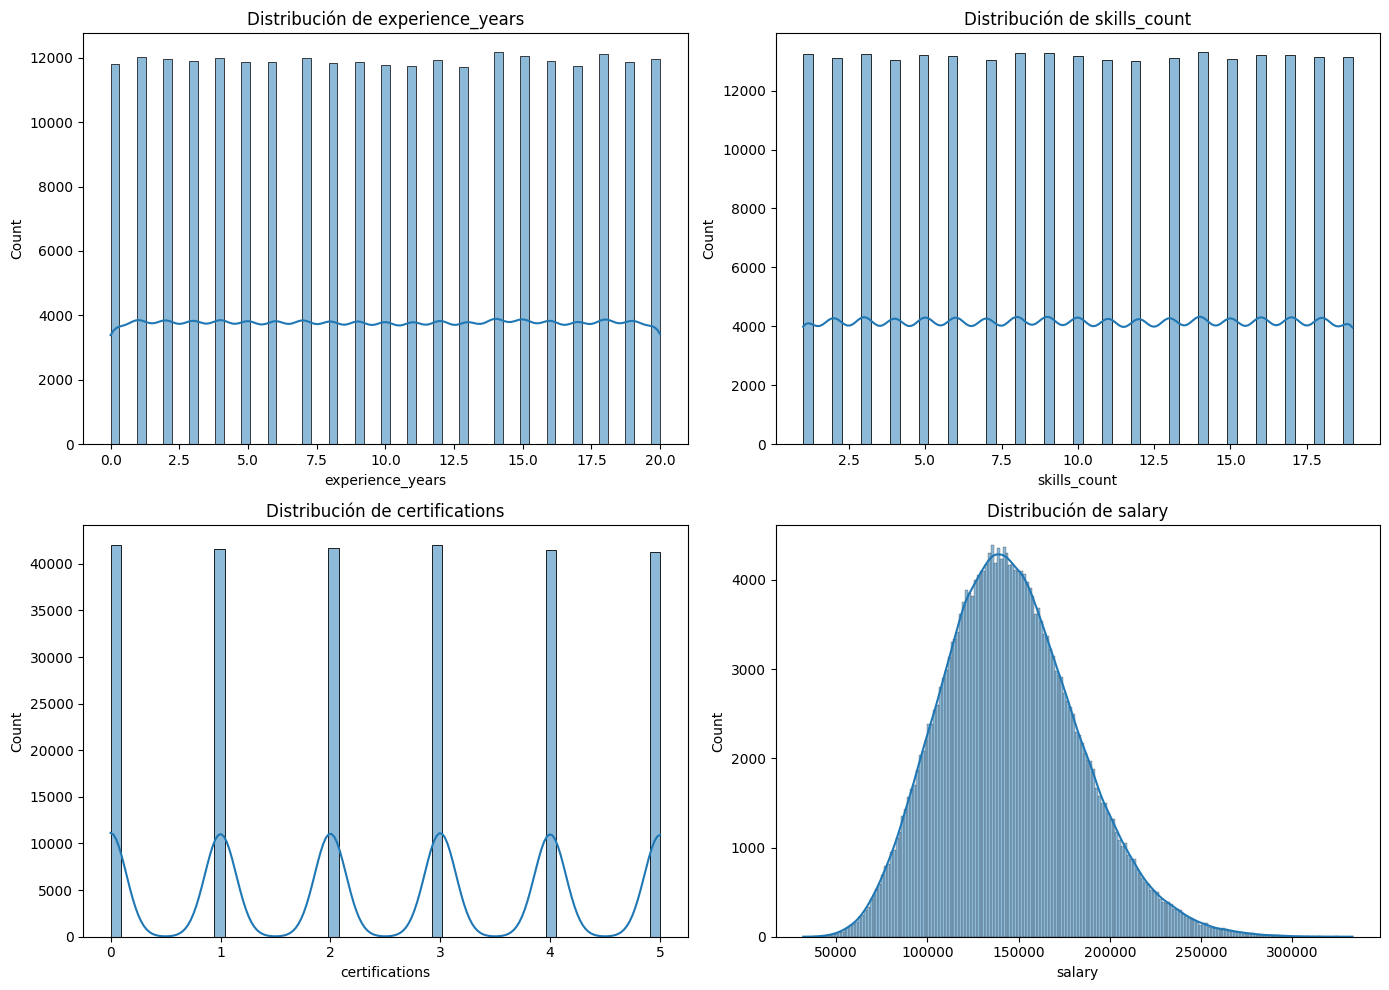

In [29]:
# Lista de variables numéricas que se analizarán
cols_numericas = ['experience_years', 'skills_count', 'certifications', 'salary']

# Definimos el tamaño general de la figura
plt.figure(figsize=(14, 10))

# Creamos un histograma para cada variable numérica
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(2, 2, i)

    # Histograma con curva de densidad para observar la distribución
    sns.histplot(df[col], kde=True)

    # Título de cada gráfico
    plt.title(f'Distribución de {col}')

# Ajustamos el espacio entre gráficos
plt.tight_layout()

# Mostramos los gráficos
plt.show()

### Análisis de distribución de variables numéricas

Con el objetivo de comprender el comportamiento de las variables numéricas del dataset, se analizaron sus distribuciones mediante histogramas acompañados de curvas de densidad. Este análisis permite identificar la forma de los datos, su dispersión y posibles patrones relevantes.

En primer lugar, la variable *experience_years* presenta una distribución relativamente uniforme, lo que indica que los datos están repartidos de manera equilibrada entre los distintos niveles de experiencia. No se observa una concentración significativa en un rango específico, lo que sugiere que el dataset incluye trabajadores con diversos niveles de trayectoria laboral.

De manera similar, la variable *skills_count* también muestra una distribución uniforme. Esto implica que la cantidad de habilidades está distribuida de forma equilibrada entre los individuos, sin predominio de valores bajos o altos. Esta característica favorece el análisis, ya que evita sesgos asociados a la concentración de datos en ciertos niveles.

La variable certifications es discreta, ya que solo toma valores enteros entre 0 y 5. Además, se observa que estos valores están distribuidos de manera equilibrada, es decir, hay una cantidad similar de personas en cada nivel de certificaciones.
distribución relativamente equilibrada
En contraste, la variable *salary* muestra una distribución aproximadamente normal, caracterizada por una mayor concentración de valores en torno a un rango medio y una disminución progresiva hacia los extremos. Esto indica que la mayoría de los trabajadores percibe salarios cercanos al promedio, mientras que los valores muy altos o muy bajos son menos frecuentes.

En conjunto, estas distribuciones evidencian que las variables explicativas (experiencia, habilidades y certificaciones) presentan una buena dispersión y representatividad, lo que favorece la calidad del análisis. Asimismo, la distribución del salario permite identificar un comportamiento típico en torno a valores centrales, facilitando la interpretación de relaciones con otras variables.

## Análisis 1: Relación entre experiencia y salario
Se analiza si los años de experiencia se relacionan con el salario.

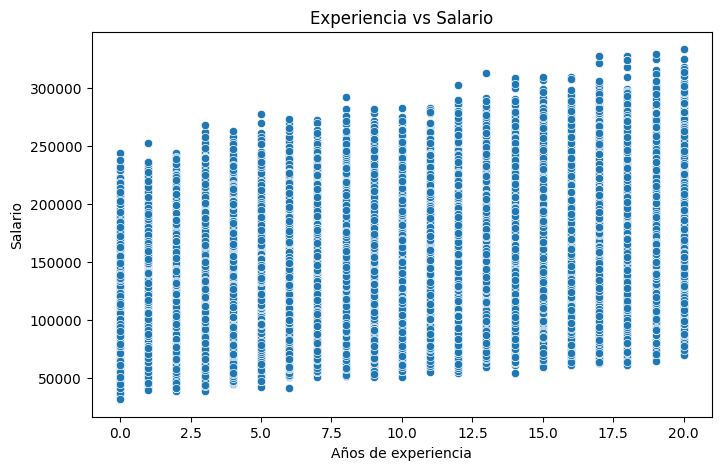

In [30]:
# Creamos una figura para el gráfico y definimos su tamaño
plt.figure(figsize=(8,5))
# Generamos un gráfico de dispersión para analizar la relación entre experiencia y salario
sns.scatterplot(data=df, x='experience_years', y='salary')
# Agregamos título y nombres a los ejes
plt.title("Experiencia vs Salario")
plt.xlabel("Años de experiencia")
plt.ylabel("Salario")
# Mostramos el gráfico
plt.show()

Aunque existe una tendencia a que el salario aumente con la experiencia, los datos muestran bastante variabilidad. Esto indica que personas con la misma experiencia pueden tener salarios diferentes, por lo que existen otros factores que también influyen en los ingresos.

## Análisis 2: Nivel educacional y salario
Se compara el salario según el nivel educacional.

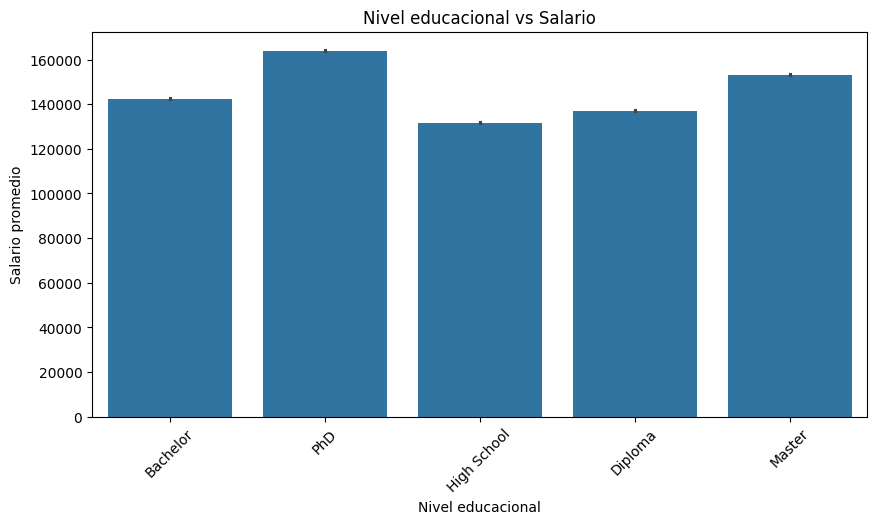

In [31]:
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(10,5))

# Creamos un gráfico de barras
# En el eje X se muestran los niveles educacionales
# En el eje Y se muestra el salario promedio para cada nivel
sns.barplot(data=df, x='education_level', y='salary')

# Agregamos el título del gráfico
plt.title("Nivel educacional vs Salario")

# Etiqueta del eje X
plt.xlabel("Nivel educacional")

# Etiqueta del eje Y
plt.ylabel("Salario promedio")

# Rotamos las etiquetas del eje X para mejorar la visualización
plt.xticks(rotation=45)

# Mostramos el gráfico
plt.show()

Se observa que el nivel educacional influye en el salario promedio. Los niveles más altos, como PhD (Doctorado) y Master, presentan mayores ingresos en comparación con niveles más bajos como High School. Esto sugiere una relación positiva entre educación y salario.

## Análisis 3: Certificaciones y salario
Se analiza cómo influye la cantidad de certificaciones en el salario.

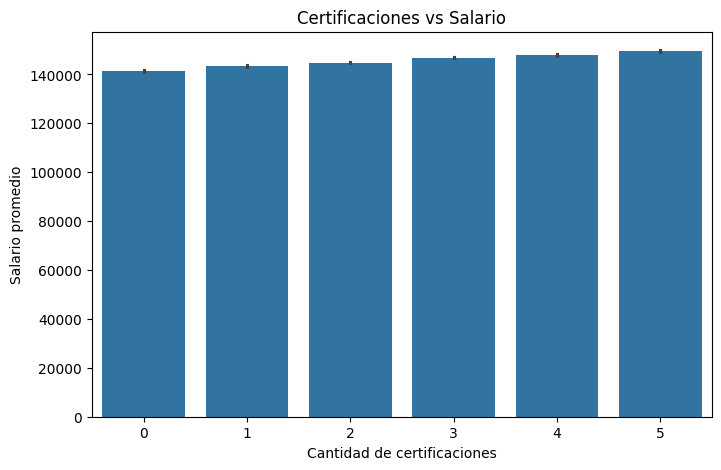

In [32]:
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(8,5))

# Creamos un gráfico de barras (barplot)
# En el eje X se muestra la cantidad de certificaciones
# En el eje Y se muestra el salario promedio para cada cantidad de certificaciones
sns.barplot(data=df, x='certifications', y='salary')

# Agregamos el título del gráfico
plt.title("Certificaciones vs Salario")

# Etiqueta del eje X
plt.xlabel("Cantidad de certificaciones")

# Etiqueta del eje Y
plt.ylabel("Salario promedio")

# Mostramos el gráfico
plt.show()

Se observa que a medida que aumenta la cantidad de certificaciones, el salario promedio tiende a incrementarse ligeramente.

Sin embargo, la variación no es muy significativa, lo que indica que la influencia de las certificaciones en el salario es relativamente baja en comparación con otras variables.

## Análisis 4: Trabajo remoto y salario
Se compara el salario según la modalidad de trabajo.

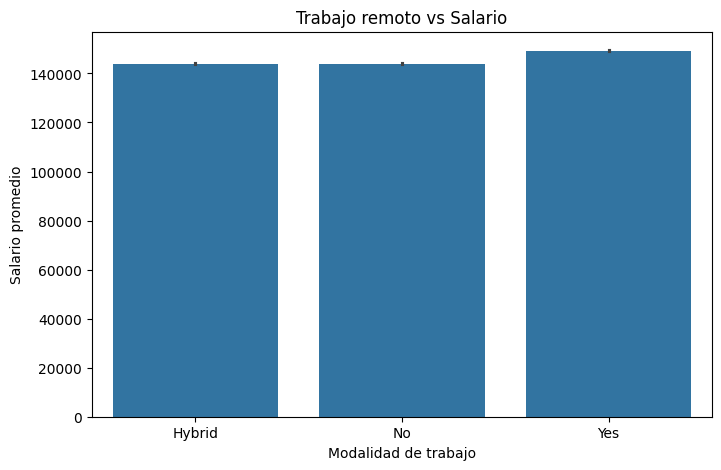

In [33]:
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(8,5))

# Creamos un gráfico de barras para comparar el salario promedio según la modalidad de trabajo
# En el eje X se muestran las categorías de trabajo remoto (Hybrid, No, Yes)
# En el eje Y se muestra el salario promedio de cada categoría
sns.barplot(data=df, x='remote_work', y='salary')

# Agregamos el título del gráfico
plt.title("Trabajo remoto vs Salario")

# Etiqueta del eje X
plt.xlabel("Modalidad de trabajo")

# Etiqueta del eje Y
plt.ylabel("Salario promedio")

# Mostramos el gráfico
plt.show()

Se observa que el salario promedio es similar entre las distintas modalidades de trabajo (remoto, presencial e híbrido).

Aunque el trabajo remoto presenta un salario ligeramente mayor, la diferencia no es significativa, lo que sugiere que la modalidad de trabajo no tiene un impacto importante en los ingresos.

# Transformación de variables categóricas a variables numéricas

En esta sección se transforman las variables categóricas del dataset a formato numérico mediante técnicas de encoding. Este proceso permite que dichas variables puedan ser utilizadas en análisis estadísticos, como la correlación, y en futuros modelos de datos, facilitando su interpretación y procesamiento.

In [34]:

from sklearn.preprocessing import LabelEncoder  # Importa herramienta para codificar variables

df_nuevo = df.copy()  # Crea una copia del dataset original

# Codifica el nivel educacional a números
le_edu = LabelEncoder()
df_nuevo['education_encoded'] = le_edu.fit_transform(df_nuevo['education_level'])

# Codifica el tamaño de empresa a números
le_size = LabelEncoder()
df_nuevo['company_size_encoded'] = le_size.fit_transform(df_nuevo['company_size'])

# Aplica One Hot Encoding a variables categóricas sin orden
df_nuevo = pd.get_dummies(df_nuevo, columns=['job_title', 'industry', 'location', 'remote_work'], drop_first=False)

# Elimina las columnas originales ya transformadas
df_nuevo = df_nuevo.drop(columns=['education_level', 'company_size'])




Para la transformación de variables categóricas a numéricas, se utilizaron distintos métodos de codificación según el tipo de variable.

En el caso de las variables ordinales, como el nivel educacional y el tamaño de la empresa, se aplicó Label Encoding, ya que estas poseen un orden natural entre sus categorías, lo que permite representarlas adecuadamente mediante valores numéricos.

Por otro lado, para las variables nominales, como el cargo, la industria, la ubicación y la modalidad de trabajo, se utilizó One Hot Encoding. Este método crea variables binarias independientes para cada categoría, evitando así introducir relaciones de orden que no existen en la realidad.

De esta forma, se garantiza una representación adecuada de los datos para su posterior análisis.

In [35]:
# Mostramos las primeras filas del nuevo dataset para verificar los cambios
df_nuevo.head()

,experience_years,skills_count,certifications,salary,education_encoded,company_size_encoded,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,10,2,2,109413,0,2,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,5,17,0,93764,0,3,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,4,2,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,19,13,0,189123,4,2,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,0,1,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


# Diccionario - Correción

Se generaron tablas de equivalencia para las variables transformadas mediante Label Encoding.

Estas tablas permiten identificar qué categoría original representa cada valor numérico. Esto es importante porque, después de codificar las variables categóricas, los números por sí solos no permiten interpretar directamente el significado de cada categoría.

In [36]:
# Diccionario de equivalencias para variables codificadas con LabelEncoder

# Se crea una tabla para mostrar la equivalencia de la variable education_level.
# le_edu.classes_ contiene las categorías originales que tenía la columna education_level.
# le_edu.transform(le_edu.classes_) muestra el número asignado a cada categoría.
diccionario_education = pd.DataFrame({
    "Nivel educacional original": le_edu.classes_,
    "Valor codificado en education_encoded": le_edu.transform(le_edu.classes_)
})

# Se muestra la tabla de equivalencias para education_level.
# Esto permite saber qué significa cada número en la columna education_encoded.
display(diccionario_education)

,Nivel educacional original,Valor codificado en education_encoded
0,Bachelor,0
1,Diploma,1
2,High School,2
3,Master,3
4,PhD,4


In [37]:
# Tabla de equivalencias para la variable company_size

# Se crea una tabla para mostrar la equivalencia de la variable company_size.
# le_size.classes_ contiene las categorías originales que tenía la columna company_size.
# le_size.transform(le_size.classes_) muestra el número asignado a cada categoría.
diccionario_company_size = pd.DataFrame({
    "Tamaño de empresa original": le_size.classes_,
    "Valor codificado en company_size_encoded": le_size.transform(le_size.classes_)
})
# Se muestra la tabla de equivalencias para company_size.
# Esto permite saber qué significa cada número en la columna company_size_encoded.
display(diccionario_company_size)

,Tamaño de empresa original,Valor codificado en company_size_encoded
0,Enterprise,0
1,Large,1
2,Medium,2
3,Small,3
4,Startup,4


In [38]:
# Obtenemos la cantidad de filas y columnas del nuevo dataset
filas, columnas = df_nuevo.shape

print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Cantidad de filas: 250000
Cantidad de columnas: 41


### Matriz de correlación ampliada con variables categóricas transformadas

Se incluyen variables categóricas previamente transformadas mediante técnicas de encoding.

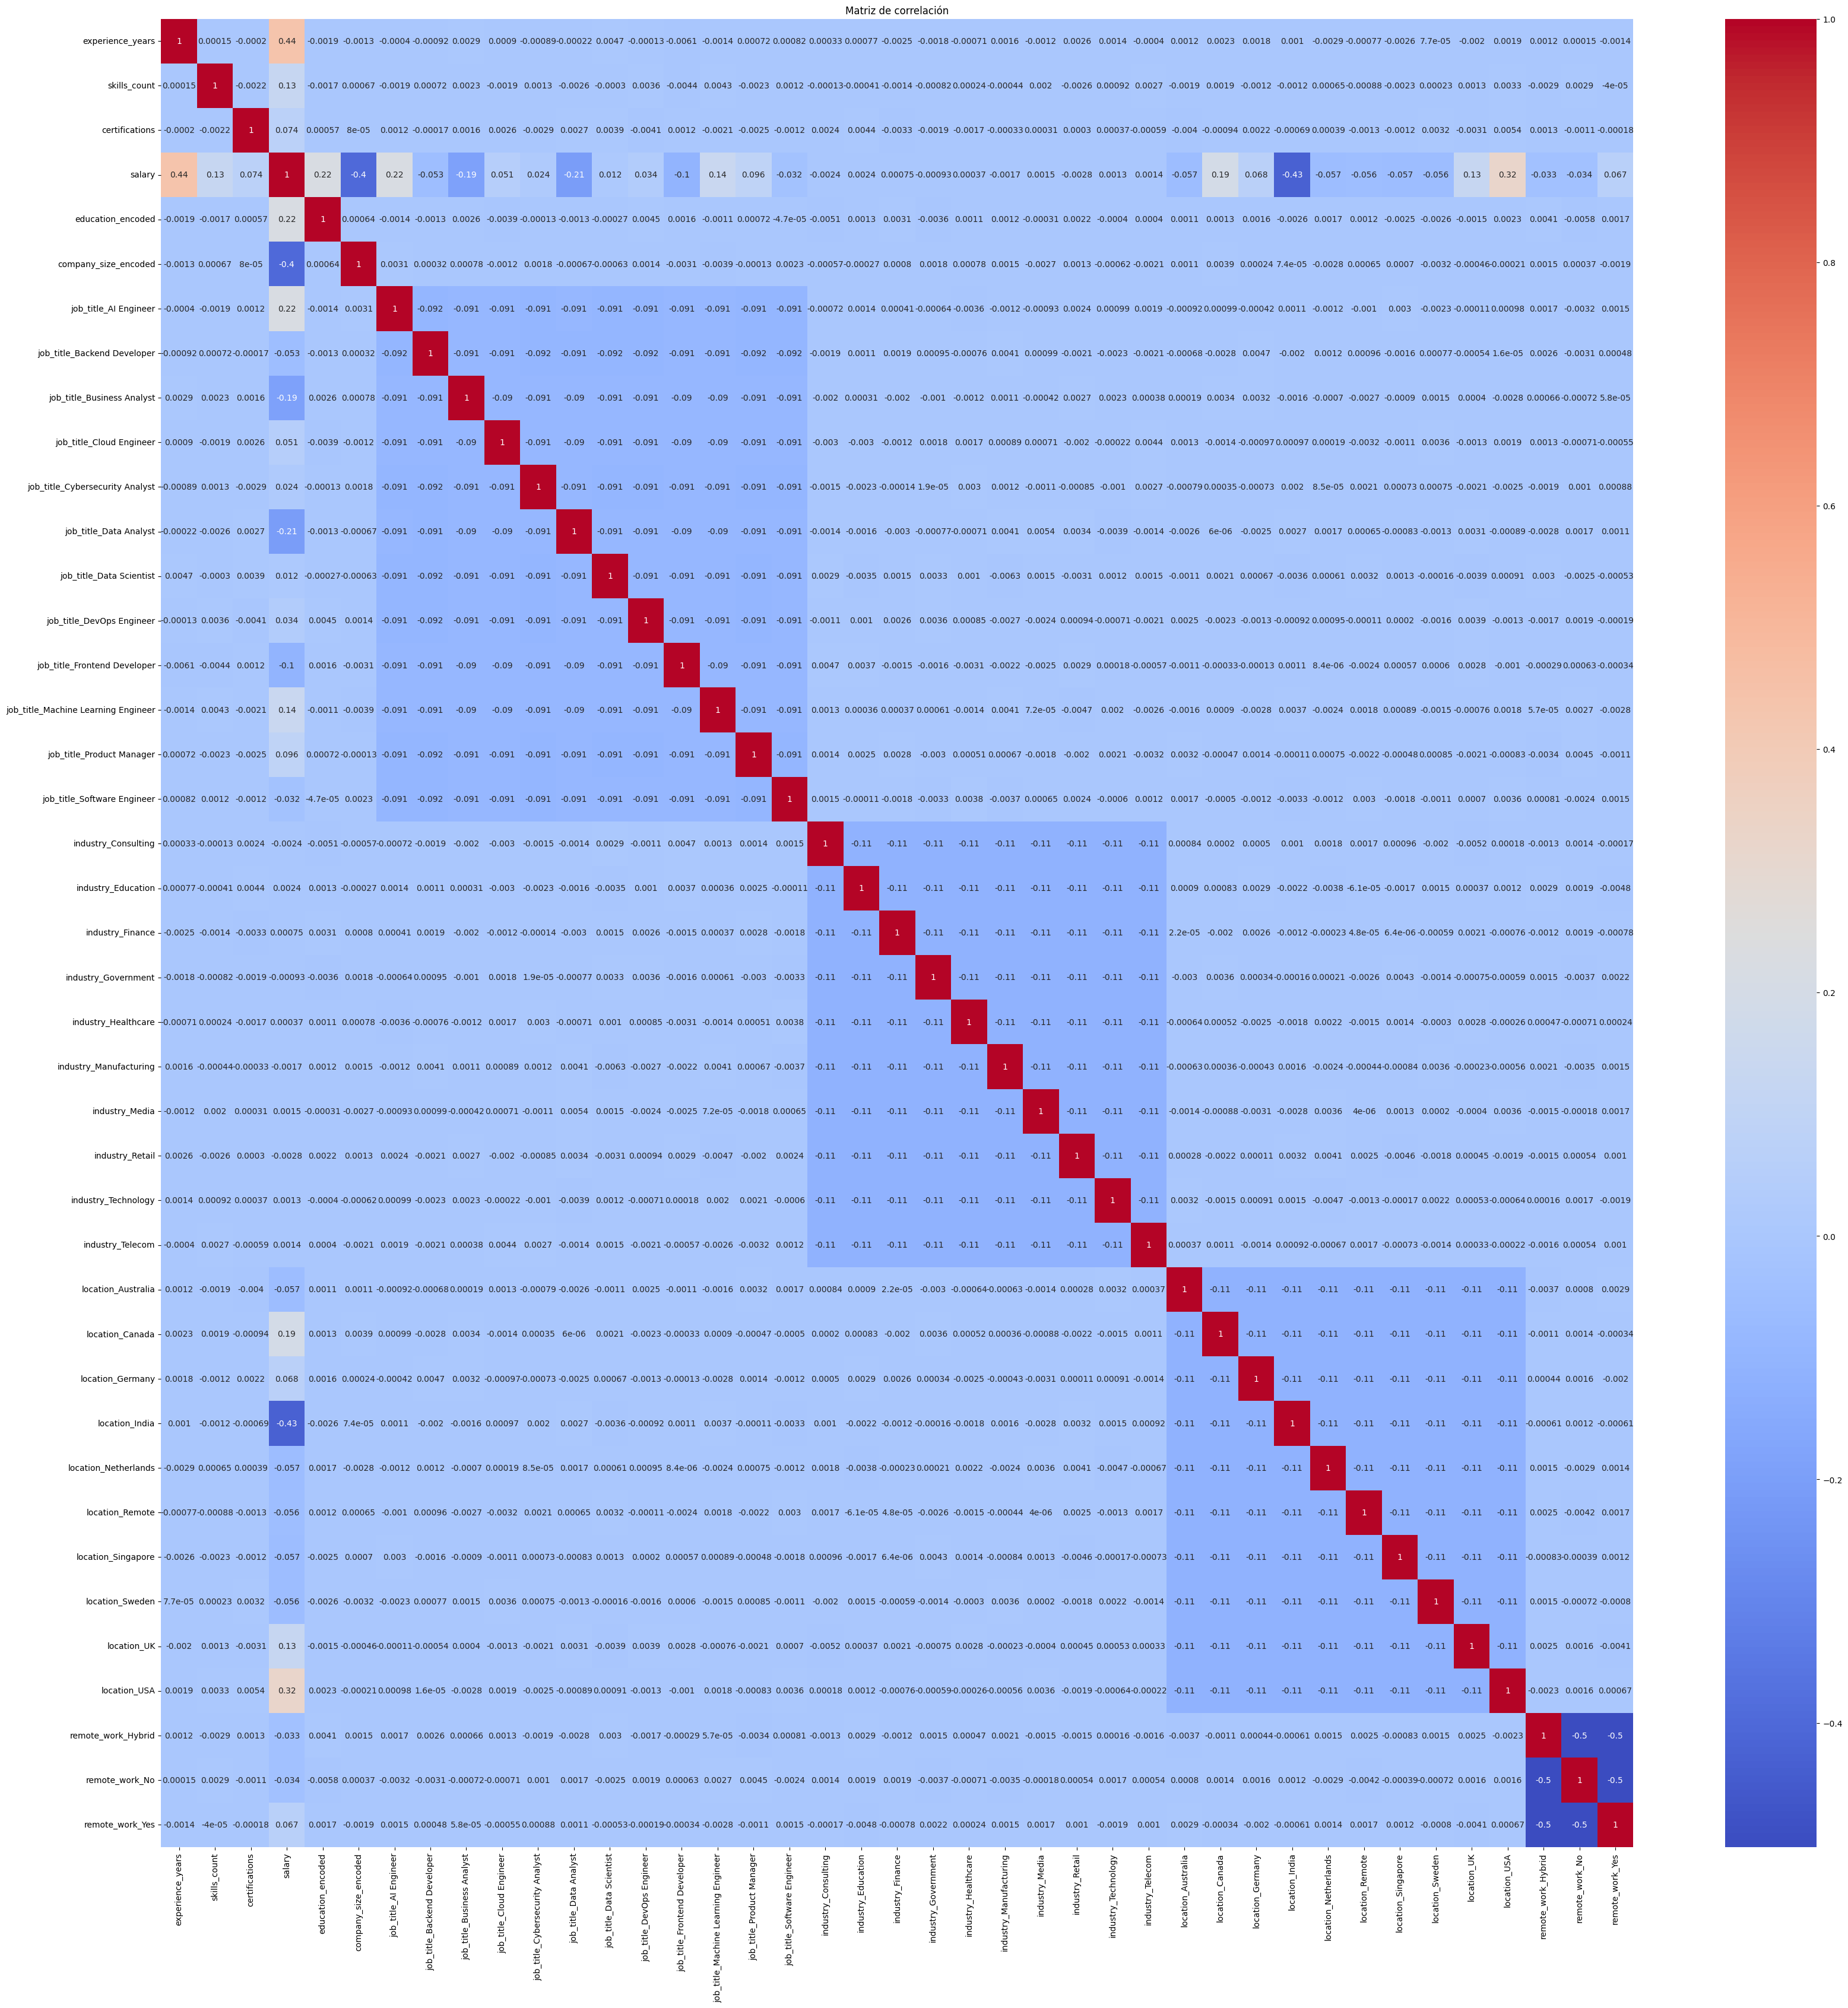

In [39]:
from numpy import true_divide
# Calculamos la matriz de correlación del dataset 'df_nuevo'
# Se consideran únicamente variables numéricas, incluyendo aquellas que fueron transformadas desde variables categóricas mediante encoding
corr_matrix = df_nuevo.corr(numeric_only=True)
# Definimos el tamaño del gráfico (ancho, alto)
plt.figure(figsize=(40, 40))

# Agregamos un título al gráfico
plt.title("Matriz de correlación")
# Creamos el heatmap (mapa de calor) para visualizar la correlación
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# Mostramos el gráfico en pantalla
plt.show()

La matriz de correlación permite observar qué tan relacionadas están las variables entre sí. Los valores van desde -1 hasta 1: mientras más cerca de 1, más positiva es la relación; mientras más cerca de -1, más negativa; y mientras más cerca de 0, menor relación existe.

En esta matriz se observa que la variable que presenta mayor relación con el salario es experience_years, con una correlación aproximada de 0.44. Esto indica una relación positiva moderada, a mayor experiencia laboral, el salario tiende a aumentar.

También se observa que education_encoded tiene una relación positiva con el salario, aproximadamente de 0.22. Esto sugiere que el nivel educacional influye en los ingresos, aunque con menor fuerza que la experiencia.

Por otra parte, skills_count y certifications presentan correlaciones más bajas con el salario, aproximadamente 0.13 y 0.07 respectivamente. Esto significa que, aunque pueden tener cierta influencia, su relación con el salario es débil dentro de este dataset.

En el caso de las variables transformadas mediante One Hot Encoding, como remote_work y location, aparecen algunas correlaciones negativas entre categorías. Esto es normal, ya que estas variables funcionan de forma excluyente: por ejemplo, si una persona pertenece a una modalidad de trabajo, no puede pertenecer al mismo tiempo a otra. Por eso, algunas categorías aparecen con valores negativos entre sí.

Respecto a las ubicaciones, se observan diferencias según el país. Algunas ubicaciones presentan correlación positiva con el salario, mientras que otras presentan correlación negativa. Esto sugiere que la ubicación puede influir en el salario, aunque no todas las regiones o países tienen el mismo efecto.

En general, la matriz muestra que no existe una sola variable que explique completamente el salario. La experiencia es el factor más relevante, seguida por el nivel educacional, pero el salario parece depender de una combinación de factores como experiencia, educación, modalidad de trabajo, ubicación y otras características laborales.

### Identificación de outliers en variables numéricas

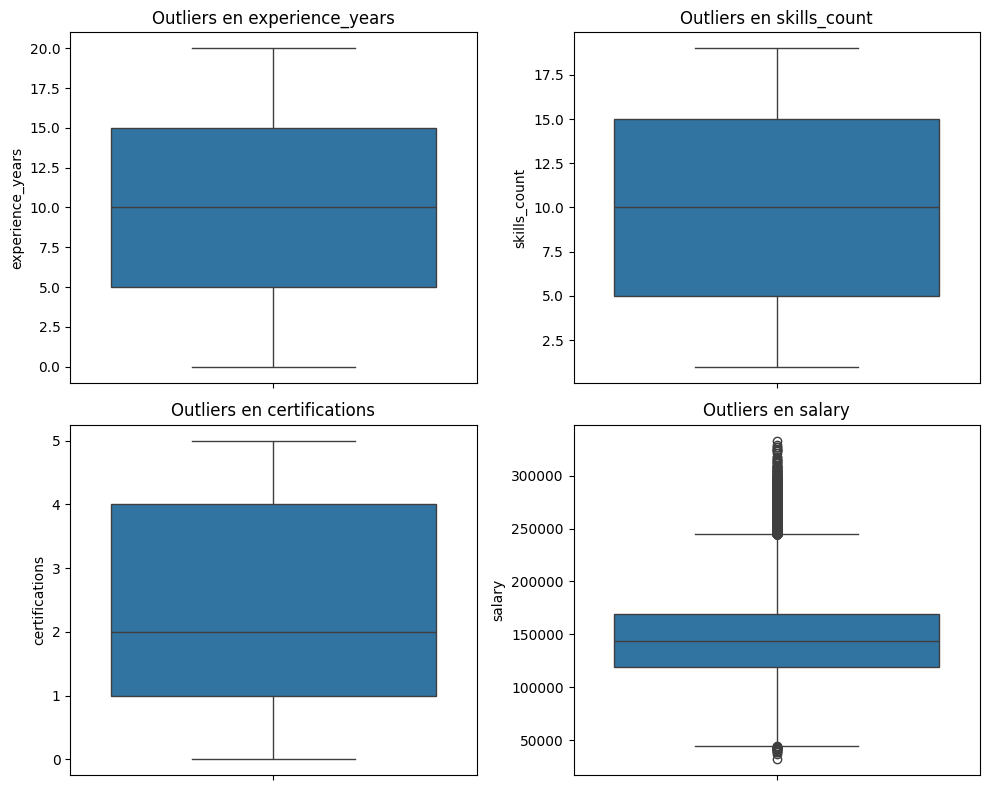

In [40]:
# Definimos las columnas numéricas que queremos analizar
cols_numericas = ['experience_years', 'skills_count', 'certifications', 'salary']

# Creamos una figura general donde irán todos los gráficos
# figsize define el tamaño de la imagen (ancho, alto)
plt.figure(figsize=(10, 8))

# Recorremos cada columna junto con su posición (i)
for i, col in enumerate(cols_numericas, 1):

    # 2 filas, 2 columnas, posición i
    plt.subplot(2, 2, i)

    # Creamos el boxplot (gráfico de caja) de la variable actual
    # Usamos 'y' para que el gráfico sea vertical
    sns.boxplot(y=df[col])

    # Agregamos un título a cada gráfico
    plt.title(f'Outliers en {col}')

# Ajustamos automáticamente los espacios entre gráficos
# Evita que se sobrepongan títulos o ejes
plt.tight_layout()

# Mostramos la figura completa con todos los gráficos
plt.show()

En los gráficos tipo boxplot se observa la distribución de las variables numéricas y la presencia de posibles valores atípicos (outliers).

En el caso de *experience_years*, se aprecia una distribución relativamente uniforme, con valores que se concentran entre aproximadamente 5 y 15 años de experiencia, sin evidencia de outliers significativos. Esto indica que la mayoría de los datos se encuentran dentro de un rango esperado.

De manera similar, la variable *skills_count* presenta una distribución equilibrada, con valores concentrados en torno al rango medio, sin presencia de valores atípicos, lo que sugiere consistencia en la cantidad de habilidades reportadas.

Para la variable *certifications*, se observa una menor dispersión de los datos, concentrándose principalmente entre 1 y 4 certificaciones. Tampoco se identifican outliers relevantes, lo que indica estabilidad en esta variable.

Por otro lado, la variable *salary* presenta una mayor dispersión y una clara presencia de valores atípicos, tanto en la parte superior como inferior. Esto indica que existen salarios significativamente más altos y más bajos que el promedio, lo que refleja una mayor variabilidad en los ingresos dentro del dataset.

En general, se concluye que la variable salario es la que presenta mayor variabilidad y presencia de valores extremos, mientras que las demás variables muestran distribuciones más estables y sin outliers significativos.

### Estandarización de variables numéricas

La estandarización transforma los datos para que tengan una escala común, donde los valores cercanos a 0 representan el promedio, los positivos están sobre el promedio y los negativos por debajo.

In [41]:
from sklearn.preprocessing import StandardScaler

# 1. Definimos las columnas numéricas a estandarizar
cols_a_escalar = ['experience_years', 'skills_count', 'certifications', 'salary']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Creamos una copia del dataset para no modificar el original
df_escalado = df.copy()

# 4. Aplicamos la estandarización
df_escalado[cols_a_escalar] = scaler.fit_transform(df_escalado[cols_a_escalar])

# 5. Verificamos los resultados
print("Primeras filas con datos estandarizados:")
print(df_escalado[cols_a_escalar].head())

Primeras filas con datos estandarizados:
   experience_years  skills_count  certifications    salary
0         -0.000892     -1.459647       -0.288272 -0.970520
1         -0.825894      1.277940       -1.460281 -1.388854
2          1.319111     -1.094636       -0.874276  0.064289
3          1.484112      0.547917       -1.460281  1.160315
4          0.824110     -0.547118       -1.460281  0.517295


A partir de los valores estandarizados, es posible interpretar cada observación en relación con el promedio de las variables.

Por ejemplo, en la primera fila se observa que el valor de *salary* es -0.97, lo que indica que este salario se encuentra por debajo del promedio del dataset. Además, el valor de *skills_count* es -1.45, lo que sugiere que esta persona posee una cantidad de habilidades considerablemente menor al promedio.

En la segunda fila, el valor de *salary* es -1.38, reflejando un salario aún más bajo que el promedio. A su vez, el valor de *certifications* es -1.46, lo que indica que también cuenta con menos certificaciones que la mayoría de los individuos del dataset.

Por otro lado, en la tercera fila, el valor de *experience_years* es 1.31, lo que representa un nivel de experiencia superior al promedio. Sin embargo, su *salary* es cercano a 0 (0.06), lo que indica que su ingreso se encuentra en torno al promedio, evidenciando que una mayor experiencia no siempre se traduce directamente en un salario más alto.

Finalmente, en la cuarta fila, se observa un valor de *salary* de 1.16, lo que indica un salario superior al promedio. Este caso también presenta un valor positivo en *experience_years* (1.48), lo que sugiere que una mayor experiencia podría estar asociada a mayores ingresos en ciertos casos.

# Conclusión
En conclusión, el análisis exploratorio permitió identificar que la experiencia laboral es el factor con mayor relación con el salario, seguida en menor medida por el nivel educacional. No obstante, los resultados evidencian que el salario no depende de una única variable, sino de la interacción de múltiples factores, como habilidades, certificaciones, ubicación y características del trabajo, lo que refleja la complejidad del comportamiento de los ingresos en el contexto laboral.

# Modelo de Regresión Lineal Múltiple para Predicción de Salarios

En esta sección se aplica un modelo de regresión lineal múltiple con el objetivo de predecir el salario de una persona a partir de distintas variables laborales.

Se utiliza regresión lineal múltiple porque la variable objetivo, `salary`, es numérica continua,por lo cual corresponde usar un modelo de regresión, además se emplean varias variables explicativas como años de experiencia, nivel educacional, cantidad de habilidades, certificaciones, cargo, industria, ubicación, modalidad de trabajo y tamaño de empresa.

# Importación de librerías

In [42]:
# Librerías para el modelo predictivo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Preparación del dataset para el modelo

In [43]:
# Crear una copia del dataset ya transformado
df_modelo = df_nuevo.copy()

# Verificar las primeras filas
df_modelo.head()

,experience_years,skills_count,certifications,salary,education_encoded,company_size_encoded,job_title_AI Engineer,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,10,2,2,109413,0,2,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,5,17,0,93764,0,3,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,4,2,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,19,13,0,189123,4,2,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,0,1,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


Se creó una copia del dataframe `df_nuevo`, el cual contiene las variables ya transformadas y codificadas para ser utilizadas en el modelo.

Este dataframe incluye la variable objetivo `salary` y las variables explicativas necesarias para realizar la predicción.

# Revisión de columnas disponibles

In [44]:
# Revisar columnas disponibles
df_modelo.columns

Index(['experience_years', 'skills_count', 'certifications', 'salary',
       'education_encoded', 'company_size_encoded', 'job_title_AI Engineer',
       'job_title_Backend Developer', 'job_title_Business Analyst',
       'job_title_Cloud Engineer', 'job_title_Cybersecurity Analyst',
       'job_title_Data Analyst', 'job_title_Data Scientist',
       'job_title_DevOps Engineer', 'job_title_Frontend Developer',
       'job_title_Machine Learning Engineer', 'job_title_Product Manager',
       'job_title_Software Engineer', 'industry_Consulting',
       'industry_Education', 'industry_Finance', 'industry_Government',
       'industry_Healthcare', 'industry_Manufacturing', 'industry_Media',
       'industry_Retail', 'industry_Technology', 'industry_Telecom',
       'location_Australia', 'location_Canada', 'location_Germany',
       'location_India', 'location_Netherlands', 'location_Remote',
       'location_Singapore', 'location_Sweden', 'location_UK', 'location_USA',
       'remote_work

Se revisaron las columnas disponibles para confirmar que la variable objetivo `salary` se encuentra en el dataset y que las demás variables pueden ser utilizadas como variables explicativas.

# Definición de variable objetivo y variables explicativas

In [45]:
# Variable objetivo
y = df_modelo["salary"]

# Variables explicativas
X = df_modelo.drop(columns=["salary"])

# Convertir todas las variables explicativas a formato numérico
X = X.astype(float)

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (250000, 40)
Tamaño de y: (250000,)


En esta etapa se separaron las variables del modelo.

La variable `y` corresponde a `salary`, que es el salario que se desea predecir.

La variable `X` contiene las variables explicativas que serán utilizadas por el modelo, como experiencia, habilidades, certificaciones, educación, tamaño de empresa, cargo, industria, ubicación y modalidad de trabajo.

# División de datos en entrenamiento y prueba

In [46]:
# División del dataset en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (200000, 40)
X_test: (50000, 40)
y_train: (200000,)
y_test: (50000,)


El dataset fue dividido en datos de entrenamiento y datos de prueba.

El 80% de los datos se utilizó para entrenar el modelo, mientras que el 20% restante se utilizó para evaluar su desempeño con datos que el modelo no había visto antes.

# Escalamiento de variables

In [47]:
# Escalamiento de variables explicativas

scaler_modelo = StandardScaler()

X_train_scaled = scaler_modelo.fit_transform(X_train)
X_test_scaled = scaler_modelo.transform(X_test)

In [48]:
print(X_train.isnull().sum())

experience_years                       0
skills_count                           0
certifications                         0
education_encoded                      0
company_size_encoded                   0
job_title_AI Engineer                  0
job_title_Backend Developer            0
job_title_Business Analyst             0
job_title_Cloud Engineer               0
job_title_Cybersecurity Analyst        0
job_title_Data Analyst                 0
job_title_Data Scientist               0
job_title_DevOps Engineer              0
job_title_Frontend Developer           0
job_title_Machine Learning Engineer    0
job_title_Product Manager              0
job_title_Software Engineer            0
industry_Consulting                    0
industry_Education                     0
industry_Finance                       0
industry_Government                    0
industry_Healthcare                    0
industry_Manufacturing                 0
industry_Media                         0
industry_Retail 

Se aplicó estandarización a las variables explicativas para dejarlas en una escala común.

Esto es útil porque el dataset contiene variables con distintas magnitudes, como años de experiencia, cantidad de habilidades y variables codificadas.

# Creación y entrenamiento del modelo

In [49]:
# Crear el modelo de regresión lineal múltiple
modelo_regresion = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo_regresion.fit(X_train_scaled, y_train)

LinearRegression()

Se creó y entrenó un modelo de regresión lineal múltiple.

El modelo aprende la relación entre las variables explicativas y la variable objetivo `salary`, buscando estimar el salario a partir de las características laborales disponibles.
Se creó y entrenó un modelo de regresión lineal múltiple utilizando los datos de entrenamiento.  
La salida `LinearRegression()` indica que el modelo fue creado correctamente y quedó listo para realizar predicciones sobre nuevos datos.

# Predicción con datos de prueba


In [50]:
# Realizar predicciones con los datos de prueba
y_pred = modelo_regresion.predict(X_test_scaled)

# Comparar valores reales y predichos
resultados = pd.DataFrame({
    "Salario real": y_test,
    "Salario predicho": y_pred
})

resultados.head(10)

,Salario real,Salario predicho
38683,164009,161493.790637
64939,79594,88281.487431
3954,74090,52385.216652
120374,177193,163906.505060
172861,120012,120665.374352
149303,163369,182880.945901
111626,111889,108276.379543
164553,75418,75292.417726
55779,103067,85393.310182
141990,190692,183073.229562


Después de entrenar el modelo, se realizaron predicciones utilizando el conjunto de prueba.

La tabla permite comparar algunos salarios reales con los salarios estimados por el modelo.
Después de entrenar el modelo, se realizaron predicciones utilizando el conjunto de prueba. La tabla compara los salarios reales con los salarios estimados por el modelo.

La columna `Salario real` corresponde al valor original del dataset, mientras que `Salario predicho` corresponde a la estimación generada por la regresión lineal múltiple.

Al comparar ambos valores se puede observar qué tan cerca estuvo el modelo en cada caso. Algunas predicciones se aproximan bastante al salario real, mientras que otras presentan diferencias mayores. Esto es esperable, ya que el modelo busca representar una tendencia general y no necesariamente predecir de forma exacta cada registro individual.

# Evaluación del modelo

In [51]:
# Evaluación del modelo

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 8785.455327270964
MSE: 121835059.73599921
RMSE: 11037.891996934886
R²: 0.9123402780182125


El modelo fue evaluado utilizando las métricas MAE, MSE, RMSE y R².

El MAE indica el error promedio absoluto entre los salarios reales y los salarios predichos.

El RMSE representa el error promedio del modelo, penalizando más los errores grandes.

El R² indica qué proporción de la variabilidad del salario logra explicar el modelo. Mientras más cercano a 1 sea este valor, mejor es el ajuste del modelo.

El valor de R² fue de 0,9123, lo que indica que el modelo logra explicar aproximadamente el 91,23% de la variabilidad del salario. Esto representa un buen ajuste, ya que gran parte de las diferencias salariales pueden ser explicadas por las variables utilizadas en el modelo.

En general, los resultados muestran que la regresión lineal múltiple tiene un buen desempeño para estimar salarios dentro de este dataset, aunque las predicciones deben interpretarse como aproximaciones y no como valores exactos.

# Gráfico de salarios reales vs salarios predichos

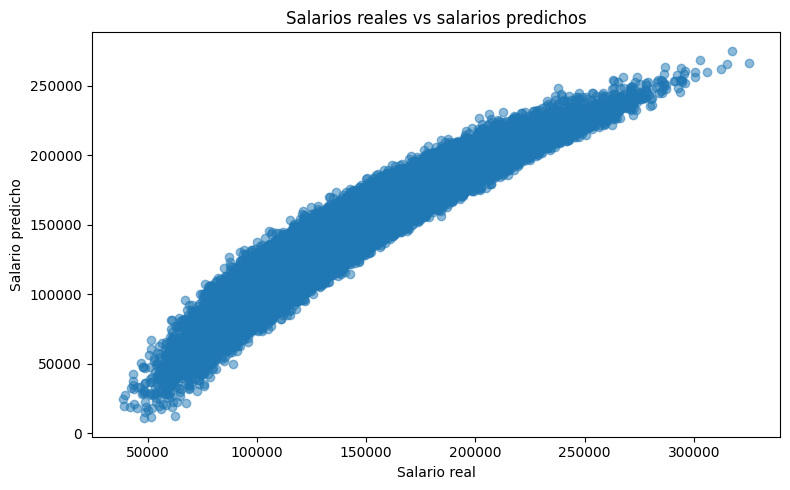

In [52]:
# Gráfico de comparación entre salarios reales y predichos

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.title("Salarios reales vs salarios predichos")
plt.xlabel("Salario real")
plt.ylabel("Salario predicho")

plt.tight_layout()
plt.show()

El gráfico permite comparar visualmente los salarios reales con los salarios predichos por el modelo.

Mientras más cerca estén los puntos de una línea diagonal imaginaria, mejor será el desempeño del modelo.

# Coeficientes del modelo

In [53]:
# Coeficientes del modelo

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_regresion.coef_
})

# Ordenar por importancia absoluta
coeficientes["Importancia_abs"] = coeficientes["Coeficiente"].abs()

coeficientes = coeficientes.sort_values(
    by="Importancia_abs",
    ascending=False
)

display(coeficientes.head(15))

,Variable,Coeficiente,Importancia_abs
0,experience_years,16355.952081,16355.952081
4,company_size_encoded,-15005.174930,15005.174930
30,location_India,-14393.943850,14393.943850
36,location_USA,10666.504985,10666.504985
3,education_encoded,8372.203855,8372.203855
5,job_title_AI Engineer,7767.926416,7767.926416
10,job_title_Data Analyst,-7094.003889,7094.003889
28,location_Canada,6528.713396,6528.713396
7,job_title_Business Analyst,-6465.382242,6465.382242
14,job_title_Machine Learning Engineer,4798.338428,4798.338428


Los coeficientes permiten observar qué variables tienen mayor influencia dentro del modelo.

Un coeficiente positivo indica que, al aumentar esa variable, el salario tiende a aumentar.

Un coeficiente negativo indica que, al aumentar esa variable, el salario tiende a disminuir.

Como las variables fueron estandarizadas, los coeficientes permiten comparar la importancia relativa de cada variable dentro del modelo.

# Función para predecir un salario

In [54]:
def predecir_salario(
    job_title,
    experience_years,
    education_level,
    skills_count,
    certifications,
    company_size,
    industry,
    location,
    remote_work
):
    # Crear una fila vacía con las mismas columnas usadas en X
    nuevo_registro = pd.DataFrame(0, index=[0], columns=X.columns)

    # Variables numéricas
    nuevo_registro["experience_years"] = experience_years
    nuevo_registro["skills_count"] = skills_count
    nuevo_registro["certifications"] = certifications

    # Variables ordinales codificadas con LabelEncoder
    nuevo_registro["education_encoded"] = le_edu.transform([education_level])[0]
    nuevo_registro["company_size_encoded"] = le_size.transform([company_size])[0]

    # Variables categóricas con One Hot Encoding
    columnas_categoricas = {
        "job_title": job_title,
        "industry": industry,
        "location": location,
        "remote_work": remote_work
    }

    for columna, valor in columnas_categoricas.items():
        nombre_columna = f"{columna}_{valor}"

        if nombre_columna in nuevo_registro.columns:
            nuevo_registro[nombre_columna] = 1

    # Escalar el nuevo registro
    nuevo_registro_scaled = scaler_modelo.transform(nuevo_registro)

    # Realizar predicción
    salario_predicho = modelo_regresion.predict(nuevo_registro_scaled)

    return salario_predicho[0]

Se creó una función para utilizar el modelo entrenado con nuevos datos.

La función recibe características laborales de una persona y devuelve una estimación de salario según los patrones aprendidos por el modelo.

# Ejemplo de uso de la función

In [55]:
# Ejemplo de uso de la función con valores existentes en el dataset

salario_estimado = predecir_salario(
    job_title="Data Scientist",
    experience_years=5,
    education_level="Bachelor",
    skills_count=8,
    certifications=2,
    company_size="Medium",
    industry="Technology",
    location="USA",
    remote_work="Hybrid"
)

print(f"Salario estimado: ${salario_estimado:,.2f}")

Salario estimado: $152,747.43


El modelo estimó un salario para un perfil con cargo de Data Scientist, 5 años de experiencia, nivel educacional Bachelor, 8 habilidades, 2 certificaciones, empresa mediana, industria tecnológica, ubicación en USA y modalidad híbrida.

Este resultado corresponde a una predicción generada por el modelo de regresión lineal múltiple, por lo que debe interpretarse como una estimación y no como un valor exacto.

## Conclusión del Modelo de Regresión Lineal

En esta segunda parte se aplicó un modelo de regresión lineal múltiple para predecir el salario de una persona a partir de distintas variables laborales.

La variable objetivo fue `salary`, mientras que las variables explicativas incluyeron años de experiencia, cantidad de habilidades, certificaciones, nivel educacional, tamaño de empresa, cargo, industria, ubicación y modalidad de trabajo.

El uso de regresión lineal múltiple fue adecuado porque el salario es una variable numérica y puede estar relacionado con múltiples factores laborales.

El modelo fue evaluado mediante métricas como MAE, MSE, RMSE y R², las cuales permiten medir qué tan cercanas fueron las predicciones respecto a los valores reales.

Además, se creó una función de predicción que permite ingresar un nuevo perfil laboral y obtener una estimación de salario.



# Segundo Modelo: Árbol de Decisión para Regresión

En esta sección se aplica un modelo de Árbol de Decisión para Regresión con el objetivo de predecir la variable `salary`.

Se eligió este modelo porque el salario es una variable numérica y continua, por lo tanto corresponde a un problema de regresión. A diferencia de la regresión lineal múltiple, el árbol de decisión no asume una relación lineal entre las variables explicativas y la variable objetivo.

El modelo divide los datos en diferentes ramas según las variables explicativas, como años de experiencia, nivel educacional, cargo, industria, ubicación, modalidad de trabajo, certificaciones y tamaño de empresa. De esta forma, busca encontrar patrones que permitan estimar el salario de una persona.

### Proceso del modelo

El modelo se desarrolla utilizando datos de entrenamiento y datos de prueba.

Primero, el dataset se divide en dos grupos de registros. Una parte se utiliza para entrenar el modelo y otra parte se reserva para probarlo. Es importante aclarar que `X_train` y `X_test` contienen las mismas variables explicativas, pero corresponden a filas o registros distintos del dataset.

`X_train` contiene las características de los registros usados para entrenar el modelo, como años de experiencia, nivel educacional, cargo, industria, ubicación, modalidad de trabajo, certificaciones y tamaño de empresa.

`y_train` contiene los salarios reales correspondientes a esos mismos registros de entrenamiento. Es decir, son las respuestas correctas que el modelo utiliza para aprender la relación entre las características laborales y el salario.

`X_test` contiene las mismas variables explicativas que `X_train`, pero de registros que fueron separados para prueba. Estos registros no se usan durante el entrenamiento, sino que sirven para evaluar si el modelo puede funcionar bien con datos nuevos.

`y_test` contiene los salarios reales de esos registros de prueba. Estos valores se comparan después con las predicciones generadas por el modelo.

Luego se crea el modelo con `DecisionTreeRegressor`, que corresponde a un Árbol de Decisión para Regresión. Este modelo se utiliza porque la variable que se quiere predecir, `salary`, es numérica.

Después se entrena el modelo con `.fit(X_train, y_train)`. El método `.fit()` permite que el modelo aprenda patrones entre las variables explicativas y el salario real. En el caso del árbol, el modelo aprende qué preguntas o divisiones ayudan a separar mejor los distintos niveles de salario.

Posteriormente, se realizan predicciones con `.predict(X_test)`. El método `.predict()` usa las reglas aprendidas durante el entrenamiento para estimar salarios en registros que el modelo no vio al aprender.

Finalmente, se comparan los salarios predichos con los salarios reales del conjunto de prueba. Para evaluar el desempeño se utilizan métricas como MAE, RMSE y R².

In [56]:
# Librerías para Árbol de Decisión de Regresión

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree

### Selección de profundidad del Árbol de Decisión

Antes de definir el modelo final, se probaron distintas profundidades del árbol para evaluar su desempeño y revisar si existía posible sobreajuste.

Para esto se compararon métricas en datos de entrenamiento y prueba, observando principalmente el R² y el RMSE. Esta comparación permite verificar si el modelo aprende bien sin memorizar excesivamente los datos de entrenamiento.

In [57]:
# Evaluar posible sobreajuste comparando entrenamiento y prueba
# y comparar el rendimiento en entrenamiento y prueba.

# Lista donde se guardarán los resultados de cada profundidad evaluada
resultados_overfitting = []

# Se prueban profundidades desde 2 hasta 15
for profundidad in range(2, 16):

    # Se crea un modelo temporal de Árbol de Decisión para Regresión
    # max_depth controla la profundidad máxima del árbol
    # min_samples_leaf exige que cada hoja tenga al menos 20 registros
    # random_state permite obtener los mismos resultados al volver a ejecutar
    modelo_temp = DecisionTreeRegressor(
        max_depth=profundidad,
        min_samples_leaf=20,
        random_state=42
    )

    # Se entrena el modelo temporal con los datos de entrenamiento
    modelo_temp.fit(X_train, y_train)

    # Se realizan predicciones sobre los datos de entrenamiento
    # Esto permite ver qué tan bien aprendió el modelo con los datos que ya conocía
    y_train_pred = modelo_temp.predict(X_train)

    # Se realizan predicciones sobre los datos de prueba
    # Esto permite evaluar qué tan bien funciona el modelo con datos nuevos
    y_test_pred = modelo_temp.predict(X_test)

    # Se calcula el R² en entrenamiento
    # R² indica qué porcentaje de la variabilidad del salario explica el modelo
    r2_train = r2_score(y_train, y_train_pred)

    # Se calcula el RMSE en entrenamiento
    # RMSE mide el error promedio del modelo, penalizando más los errores grandes
    rmse_train = mean_squared_error(y_train, y_train_pred) ** 0.5

    # Métricas en prueba
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = mean_squared_error(y_test, y_test_pred) ** 0.5


 # Se guardan los resultados de la profundidad evaluada
    resultados_overfitting.append({
        "max_depth": profundidad,
        "R² entrenamiento": r2_train,
        "R² prueba": r2_test,
        "RMSE entrenamiento": rmse_train,
        "RMSE prueba": rmse_test,
        "Diferencia R²": r2_train - r2_test
    })


# Se convierten los resultados a un DataFrame para verlos como tabla
resultados_overfitting = pd.DataFrame(resultados_overfitting)

# Se muestra la tabla con los resultados
display(resultados_overfitting)

,max_depth,R² entrenamiento,R² prueba,RMSE entrenamiento,RMSE prueba,Diferencia R²
0,2,0.328750,0.325034,30674.172411,30628.586730,0.003716
1,3,0.468525,0.464070,27294.324445,27292.296600,0.004454
2,4,0.556305,0.553831,24938.652605,24902.096516,0.002474
3,5,0.627943,0.625706,22836.800243,22808.275080,0.002237
4,6,0.681309,0.679042,21135.641479,21120.776434,0.002267
5,7,0.725238,0.724968,19624.968969,19551.386841,0.000270
6,8,0.765538,0.764162,18128.729420,18104.785071,0.001376
7,9,0.804685,0.802133,16546.203266,16583.363492,0.002552
8,10,0.837448,0.833449,15094.770395,15214.576978,0.003999
9,11,0.863582,0.858276,13828.239427,14034.849863,0.005306


Esta tabla permite comparar el rendimiento del árbol con distintas profundidades.  
Si el R² de entrenamiento es mucho mayor que el R² de prueba, podría existir sobreajuste.  
En cambio, si ambos valores son cercanos, el modelo mantiene una buena capacidad de generalización.

En los resultados obtenidos, se observa que el R² de prueba aumenta a medida que crece la profundidad del árbol, mientras que el RMSE de prueba disminuye. Además, la diferencia entre el R² de entrenamiento y el R² de prueba se mantiene baja, incluso con `max_depth=15`.

Por esta razón, no se observa un sobreajuste fuerte dentro de las profundidades evaluadas. Se seleccionó `max_depth=15` porque fue la profundidad que obtuvo el mejor desempeño en el conjunto de prueba, con un R² aproximado de 0,9191 y un RMSE aproximado de 10.604,42.

In [58]:
# Crear el modelo final de Árbol de Decisión para Regresión

modelo_arbol = DecisionTreeRegressor(
    max_depth=15,         # Profundidad seleccionada según la comparación realizada
    min_samples_leaf=20,  # Evita que las hojas tengan muy pocos registros
    random_state=42       # Permite reproducir los mismos resultados
)

# Entrenar el modelo con los datos de entrenamiento
modelo_arbol.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=15, min_samples_leaf=20, random_state=42)

Se creó el modelo final de Árbol de Decisión para Regresión utilizando `max_depth=15`, ya que fue la profundidad que obtuvo el mejor desempeño dentro de las pruebas realizadas.

También se mantuvo `min_samples_leaf=20`, lo que ayuda a controlar el sobreajuste, ya que evita que el árbol cree hojas con muy pocos registros.

Luego, el modelo fue entrenado con `X_train` y `y_train`, es decir, con las variables explicativas y los salarios reales del conjunto de entrenamiento.

In [59]:
# Realizar predicciones con el conjunto de prueba

y_pred_arbol = modelo_arbol.predict(X_test)

# Comparar algunos valores reales con los valores predichos
resultados_arbol = pd.DataFrame({
    "Salario real": y_test,
    "Salario predicho árbol": y_pred_arbol
})

display(resultados_arbol.head(10))

,Salario real,Salario predicho árbol
38683,164009,164076.950000
64939,79594,93282.878049
3954,74090,70599.428571
120374,177193,165021.782609
172861,120012,121580.937348
149303,163369,174643.909091
111626,111889,122808.989362
164553,75418,72997.571429
55779,103067,92020.487805
141990,190692,193491.531250


In [60]:
# Evaluación del modelo de Árbol de Decisión

mae_arbol = mean_absolute_error(y_test, y_pred_arbol)
mse_arbol = mean_squared_error(y_test, y_pred_arbol)
rmse_arbol = mse_arbol ** 0.5
r2_arbol = r2_score(y_test, y_pred_arbol)

print("MAE Árbol:", round(mae_arbol, 2))
print("MSE Árbol:", round(mse_arbol, 2))
print("RMSE Árbol:", round(rmse_arbol, 2))
print("R² Árbol:", round(r2_arbol, 4))

MAE Árbol: 8411.65
MSE Árbol: 112453786.31
RMSE Árbol: 10604.42
R² Árbol: 0.9191


El modelo de Árbol de Decisión fue evaluado utilizando las mismas métricas aplicadas en la regresión lineal múltiple: MAE, MSE, RMSE y R².

El MAE permite conocer el error promedio absoluto entre los salarios reales y los salarios predichos.

El RMSE muestra el error promedio penalizando más los errores grandes.

El R² indica qué porcentaje de la variabilidad del salario logra explicar el modelo.

Estas métricas permiten comparar el desempeño del Árbol de Decisión con el modelo de Regresión Lineal Múltiple.

### Interpretación de la evaluación del Árbol de Decisión

El modelo de Árbol de Decisión obtuvo un **MAE de 8.411,65**, lo que significa que, en promedio, las predicciones del salario se alejan del valor real en aproximadamente 8.412 unidades salariales.

El **RMSE fue de 10.604,42**, lo que indica el error promedio del modelo considerando con mayor peso los errores grandes. Como el RMSE es mayor que el MAE, se puede interpretar que existen algunos casos donde el error de predicción es más alto.

El **R² fue de 0,9191**, lo que significa que el modelo logra explicar aproximadamente el **91,91% de la variabilidad del salario** utilizando las variables explicativas del dataset.

En general, estos resultados muestran que el Árbol de Decisión tiene un buen desempeño para predecir salarios en este conjunto de datos.

### Gráfico de salarios reales vs salarios predichos por el Árbol de Decisión

Para complementar la evaluación del modelo, se realiza una visualización que compara los salarios reales con los salarios predichos por el Árbol de Decisión.

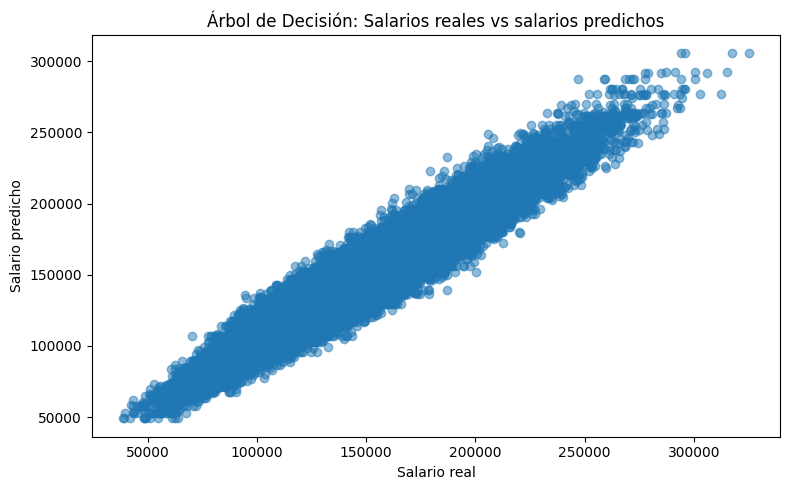

In [61]:
# Gráfico de salarios reales vs salarios predichos por el Árbol de Decisión

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_arbol, alpha=0.5)

plt.title("Árbol de Decisión: Salarios reales vs salarios predichos")
plt.xlabel("Salario real")
plt.ylabel("Salario predicho")

plt.tight_layout()
plt.show()

Cada punto representa un registro del conjunto de prueba. En el eje X está el salario real y en el eje Y está el salario predicho por el árbol. Si el punto queda cerca de la diagonal imaginaria, significa que el modelo predijo bien ese caso. Si queda lejos, significa que hubo más error. Como los puntos siguen una tendencia diagonal, el modelo logra estimar bastante bien los salarios.

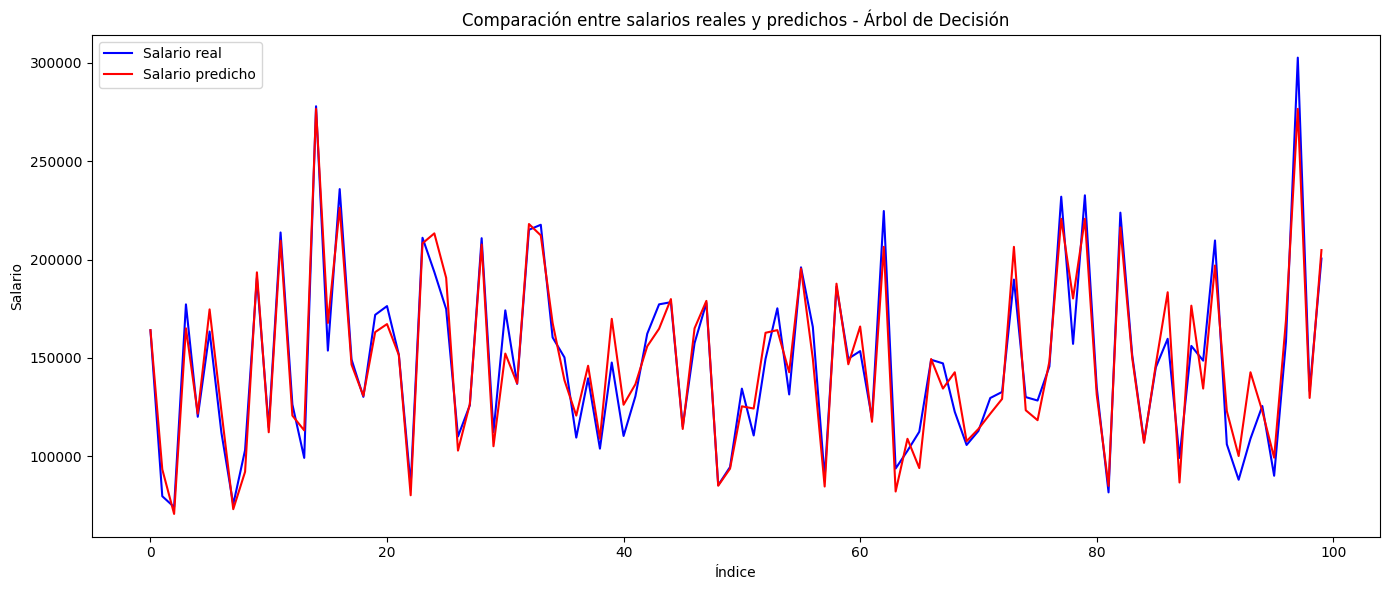

In [62]:
# Gráfico de comparación entre salarios reales y predichos por el Árbol de Decisión
# Se usa una muestra de 100 registros para que el gráfico sea más legible

# Se define la cantidad de registros que se mostrarán en el gráfico.
# En este caso, se grafican solo los primeros 100 registros del conjunto de prueba.
n = 100

# Se define el tamaño del gráfico.
plt.figure(figsize=(14, 6))

# Se grafica la línea de los salarios reales.
# range(n) genera los índices desde 0 hasta 99.
# list(y_test)[:n] toma los primeros 100 salarios reales del conjunto de prueba.
plt.plot(
    range(n),
    list(y_test)[:n],
    label="Salario real",
    color="blue"
)

# Se grafica la línea de los salarios predichos por el Árbol de Decisión.
# y_pred_arbol[:n] toma las primeras 100 predicciones realizadas por el modelo.
plt.plot(
    range(n),
    y_pred_arbol[:n],
    label="Salario predicho",
    color="red"
)

# Se agrega el título del gráfico.
plt.title("Comparación entre salarios reales y predichos - Árbol de Decisión")

# Se agrega la etiqueta del eje X.
# El índice representa la posición de cada registro dentro de la muestra graficada.
plt.xlabel("Índice")

# Se agrega la etiqueta del eje Y.
# En este eje se muestran los valores de salario.
plt.ylabel("Salario")

# Se muestra la leyenda para identificar cada línea.
plt.legend()

# Se ajusta el diseño para evitar que los textos se corten.
plt.tight_layout()

# Se muestra el gráfico final.
plt.show()

El gráfico compara los salarios reales con los salarios predichos por el modelo de Árbol de Decisión para una muestra de 100 registros del conjunto de prueba.

La línea azul representa los salarios reales, mientras que la línea roja representa los salarios estimados por el modelo. Cada posición del eje X corresponde a un registro del conjunto de prueba.

Cuando ambas líneas se encuentran cercanas, significa que el modelo realizó una predicción similar al valor real. En cambio, cuando las líneas se separan, existe un mayor error de predicción.

En general, se observa que ambas líneas siguen una tendencia similar, lo que indica que el modelo logra aproximarse de buena manera a los salarios reales.

### Visualización parcial del Árbol de Decisión

Para comprender mejor cómo el modelo toma decisiones, se visualiza una parte del Árbol de Decisión.

No se muestra el árbol completo, ya que puede ser muy extenso y difícil de interpretar. Por eso se limita la visualización a los primeros niveles del árbol.

Esta visualización permite observar qué variables utiliza el modelo en las primeras divisiones para estimar el salario.

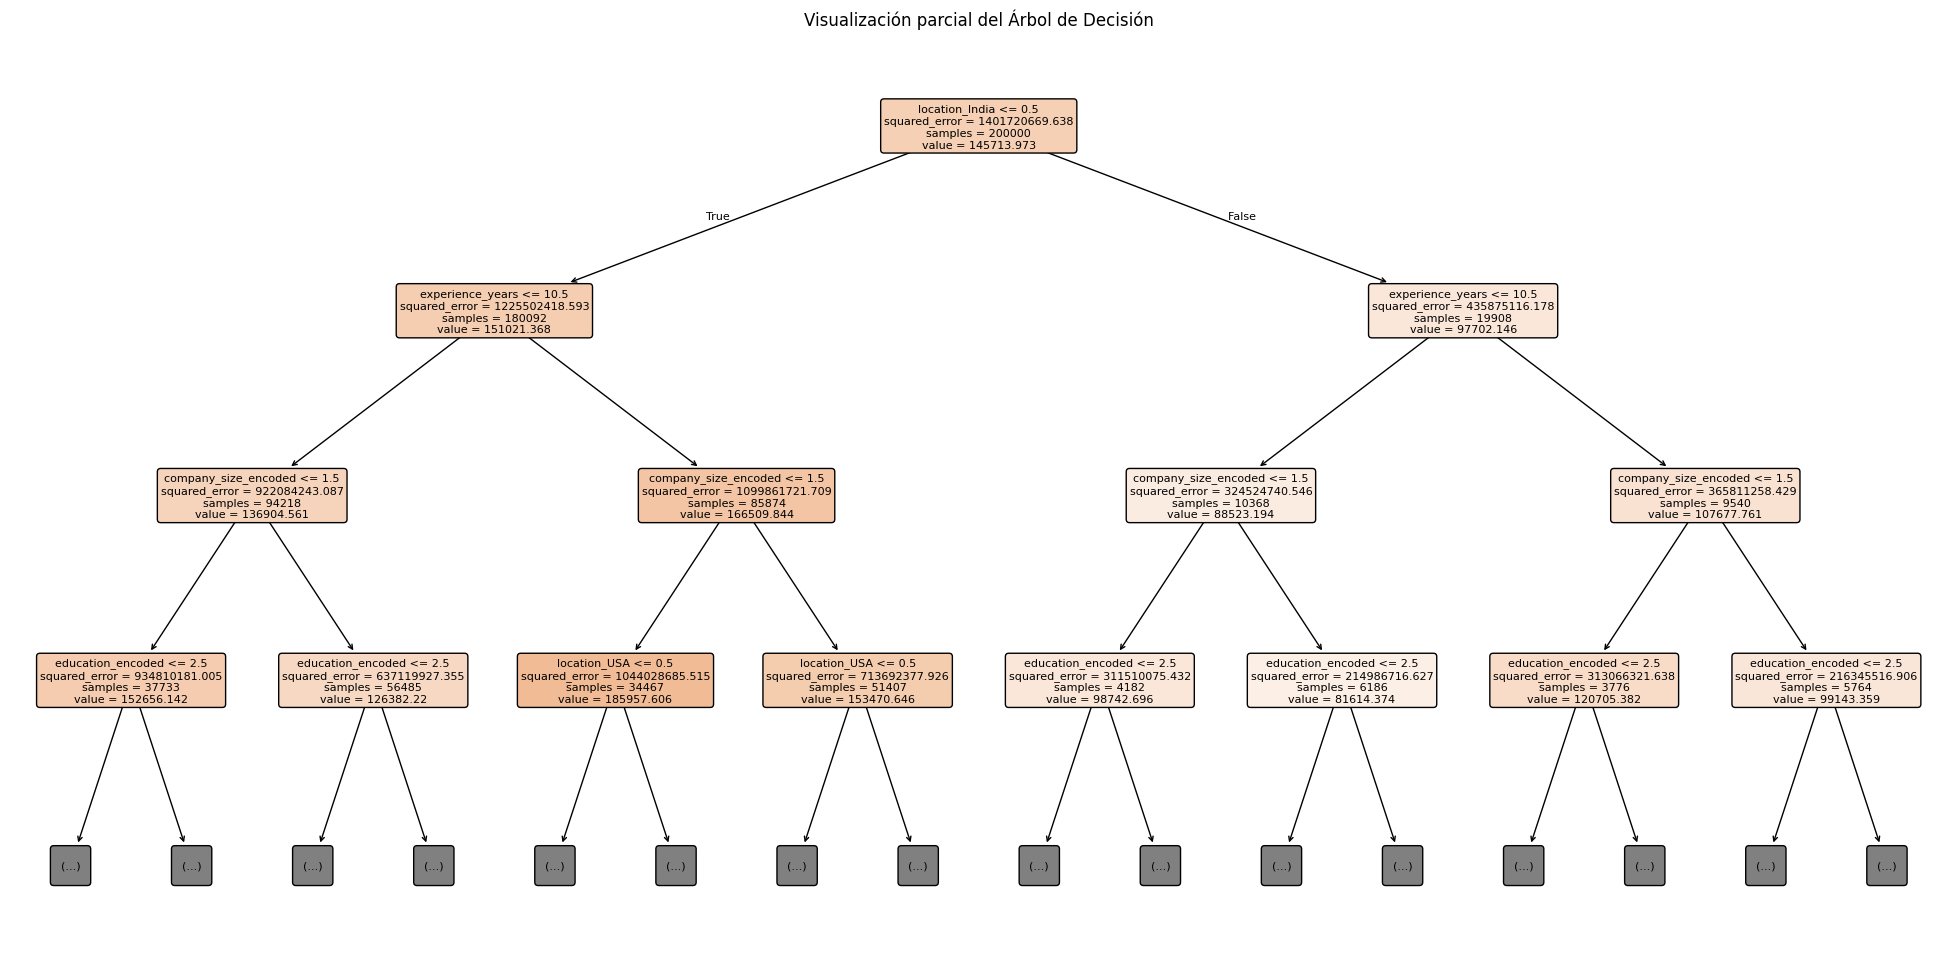

In [63]:
# Visualización parcial del Árbol de Decisión

# Se define el tamaño de la figura.
plt.figure(figsize=(25, 12))

# plot_tree permite visualizar gráficamente las divisiones del árbol.
plot_tree(
    modelo_arbol,
    feature_names=X.columns,  # Nombres de las variables explicativas utilizadas por el modelo
    filled=True,              # Colorea los nodos para facilitar la interpretación
    rounded=True,             # Redondea los bordes de los nodos
    fontsize=8,               # Tamaño de la letra dentro de los nodos
    max_depth=3               # Muestra solo los primeros 3 niveles para que sea legible
)

# Título del gráfico
plt.title("Visualización parcial del Árbol de Decisión")

# Mostrar gráfico
plt.show()

La imagen muestra una visualización parcial del Árbol de Decisión utilizado para predecir salarios. Se muestra solo una parte del árbol, ya que el modelo completo puede ser muy extenso y difícil de leer.

El árbol se interpreta desde arriba hacia abajo. Cada cuadro representa un nodo, es decir, una condición que el modelo utiliza para dividir los datos. Según si la condición se cumple o no, el registro avanza hacia una rama distinta.

La primera división del árbol se realiza con la variable `location_India <= 0.5`. Esta variable proviene del one-hot encoding, por lo que indica si el registro corresponde o no a una persona ubicada en India. El árbol eligió esta variable como primera pregunta porque fue la que permitió separar mejor los salarios al inicio del modelo.

En cada nodo aparecen tres elementos importantes:

- `squared_error`: indica qué tan dispersos están los salarios dentro de ese grupo. Mientras menor sea este valor, más parecidos son los salarios de los registros que llegaron a ese nodo.
- `samples`: indica la cantidad de registros que llegaron a ese nodo.
- `value`: representa el salario promedio estimado para los registros de ese nodo.

Por ejemplo, en el nodo inicial se observa que el modelo parte con todos los registros de entrenamiento y un salario promedio aproximado de 145.714. Luego, al dividir según `location_India`, se forman dos grupos con salarios promedio distintos. Esto muestra que la ubicación tiene una influencia importante dentro de las decisiones del árbol.

Después de la primera división, el árbol continúa realizando nuevas preguntas sobre variables como `experience_years`, `company_size_encoded`, `education_encoded` y `location_USA`. Estas divisiones permiten formar grupos cada vez más específicos para mejorar la predicción del salario.

En resumen, esta visualización permite comprender cómo el Árbol de Decisión va separando los registros mediante condiciones sucesivas hasta llegar a una estimación de salario.

### Importancia de variables

Una ventaja del Árbol de Decisión es que permite analizar qué variables fueron más importantes al momento de realizar las predicciones.

La importancia de variables indica cuánto aportó cada variable a las divisiones del árbol para reducir el error de predicción. Mientras mayor sea el valor de importancia, mayor fue el aporte de esa variable al modelo.

Es importante aclarar que esta métrica no indica si una variable aumenta o disminuye el salario, sino qué tan útil fue para separar los datos y mejorar la predicción.

In [64]:
# Importancia de variables en el Árbol de Decisión

# Se crea un DataFrame con dos columnas:
# - Variable: nombre de cada variable explicativa usada por el modelo.
# - Importancia: valor de importancia asignado por el Árbol de Decisión.
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_arbol.feature_importances_
})

# Se ordenan las variables desde la más importante hasta la menos importante.
# Esto permite identificar cuáles aportaron más al modelo.
importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

# Se muestran las 15 variables más importantes.
display(importancias.head(15))

,Variable,Importancia
0,experience_years,0.202295
30,location_India,0.195909
4,company_size_encoded,0.179714
3,education_encoded,0.098177
36,location_USA,0.082040
5,job_title_AI Engineer,0.056403
10,job_title_Data Analyst,0.039269
7,job_title_Business Analyst,0.038458
28,location_Canada,0.037117
35,location_UK,0.023072


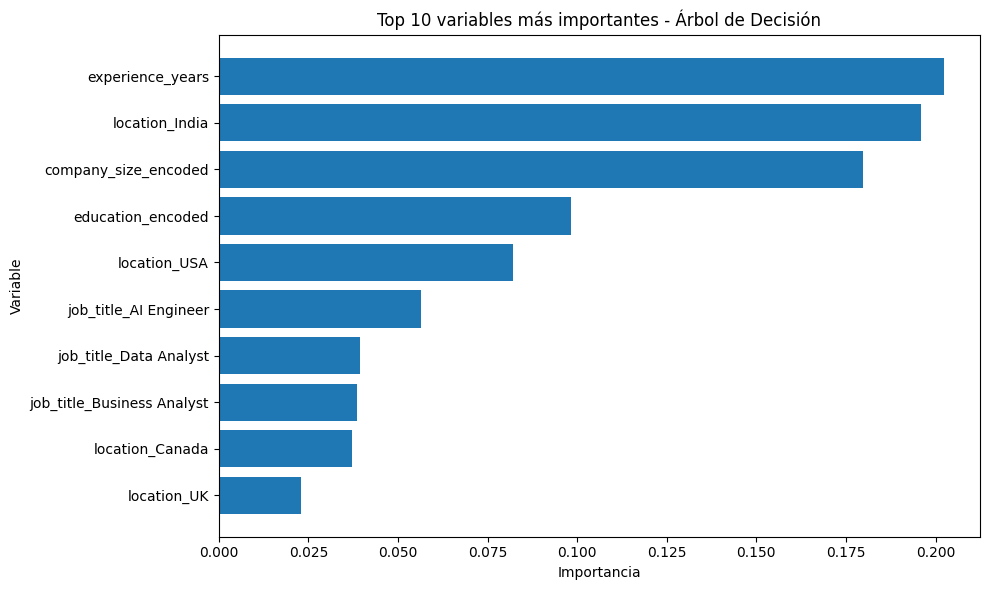

In [65]:
# Gráfico de importancia de variables

# Se seleccionan las 10 variables más importantes para que el gráfico sea legible.
top_importancias = importancias.head(10)

# Se define el tamaño del gráfico.
plt.figure(figsize=(10, 6))

# Se crea un gráfico de barras horizontal.
plt.barh(
    top_importancias["Variable"],
    top_importancias["Importancia"]
)

# Se invierte el eje Y para que la variable más importante aparezca arriba.
plt.gca().invert_yaxis()

# Título y etiquetas del gráfico.
plt.title("Top 10 variables más importantes - Árbol de Decisión")
plt.xlabel("Importancia")
plt.ylabel("Variable")

# Ajustar diseño.
plt.tight_layout()

# Mostrar gráfico.
plt.show()

La tabla y el gráfico muestran las variables que más aportaron al modelo de Árbol de Decisión para predecir el salario.

Las variables con mayor importancia fueron aquellas que el árbol utilizó con mayor peso para dividir los datos y reducir el error de predicción. En este caso, variables como los años de experiencia, la ubicación, el tamaño de empresa y el nivel educacional aparecen entre las más relevantes.

Esto es coherente con el problema analizado, ya que el salario puede depender de factores como la experiencia laboral, el país o ubicación, el nivel de estudios y el tipo de empresa.

Sin embargo, la importancia de variables no indica directamente si una variable aumenta o disminuye el salario. Solo indica qué tan relevante fue esa variable para que el modelo realizara sus predicciones.

In [66]:
def predecir_salario_arbol(
    job_title,
    experience_years,
    education_level,
    skills_count,
    certifications,
    company_size,
    industry,
    location,
    remote_work
):
    # Crear una fila vacía con las mismas columnas usadas en X
    nuevo_registro = pd.DataFrame(0, index=[0], columns=X.columns)

    # Variables numéricas
    nuevo_registro["experience_years"] = experience_years
    nuevo_registro["skills_count"] = skills_count
    nuevo_registro["certifications"] = certifications

    # Variables ordinales codificadas
    nuevo_registro["education_encoded"] = le_edu.transform([education_level])[0]
    nuevo_registro["company_size_encoded"] = le_size.transform([company_size])[0]

    # Variables categóricas con One Hot Encoding
    columnas_categoricas = {
        "job_title": job_title,
        "industry": industry,
        "location": location,
        "remote_work": remote_work
    }

    for columna, valor in columnas_categoricas.items():
        nombre_columna = f"{columna}_{valor}"

        if nombre_columna in nuevo_registro.columns:
            nuevo_registro[nombre_columna] = 1

    # Predicción con Árbol de Decisión
    salario_predicho = modelo_arbol.predict(nuevo_registro)

    return salario_predicho[0]

En esta sección se implementa una función para estimar el salario utilizando el modelo de Árbol de Decisión previamente entrenado. La función recibe como entrada las características de un perfil profesional, como cargo, años de experiencia, nivel educativo, cantidad de habilidades, certificaciones, tamaño de empresa, industria, ubicación y modalidad de trabajo.

A diferencia del modelo de regresión lineal, en este caso no se aplica escalado a los datos, ya que los Árboles de Decisión no dependen de la escala de las variables. Este tipo de modelo realiza divisiones internas a partir de condiciones sobre los valores de las variables, por ejemplo, si los años de experiencia son mayores o menores a cierto valor.

La función crea un nuevo registro con la misma estructura de columnas utilizada durante el entrenamiento del modelo, transforma las variables categóricas al formato numérico correspondiente y finalmente utiliza el modelo modelo_arbol para generar la predicción del salario.



In [67]:
salario_estimado_arbol = predecir_salario_arbol(
    job_title="Data Scientist",
    experience_years=5,
    education_level="Bachelor",
    skills_count=8,
    certifications=2,
    company_size="Medium",
    industry="Technology",
    location="USA",
    remote_work="Hybrid"
)

print(f"Salario estimado con Árbol de Decisión: ${salario_estimado_arbol:,.2f}")

Salario estimado con Árbol de Decisión: $153,772.54


El modelo de Árbol de Decisión estimó un salario de *$153,772.54* para el perfil ingresado. Este resultado es una predicción aproximada basada en los patrones aprendidos por el modelo a partir del dataset. Al igual que en la regresión lineal, el valor debe interpretarse como una estimación

## Comparación final entre modelos

En esta sección se comparan los resultados obtenidos por la Regresión Lineal Múltiple y el Árbol de Decisión para Regresión.

Ambos modelos tienen el mismo objetivo: predecir la variable `salary`. Sin embargo, utilizan enfoques distintos. La Regresión Lineal Múltiple busca una relación lineal entre las variables explicativas y el salario, mientras que el Árbol de Decisión divide los datos mediante reglas o condiciones para formar grupos con salarios similares.

In [68]:
# Comparación entre modelos

# Se crea una tabla comparativa con las métricas principales de ambos modelos.
# Estas métricas permiten evaluar cuál modelo tuvo mejor desempeño predictivo.
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Regresión Lineal Múltiple", "Árbol de Decisión"],
    "MAE": [mae, mae_arbol],
    "RMSE": [rmse, rmse_arbol],
    "R²": [r2, r2_arbol]
})

# Mostrar la tabla comparativa
display(comparacion_modelos)

,Modelo,MAE,RMSE,R²
0,Regresión Lineal Múltiple,8785.455327,11037.891997,0.91234
1,Árbol de Decisión,8411.652605,10604.422960,0.91909


Al comparar ambos modelos, se observa que el Árbol de Decisión obtuvo un desempeño levemente superior a la Regresión Lineal Múltiple.

La Regresión Lineal Múltiple obtuvo un MAE de aproximadamente 8.785,46, un RMSE de 11.037,89 y un R² de 0,9123. En cambio, el Árbol de Decisión obtuvo un MAE de aproximadamente 8.411,65, un RMSE de 10.604,42 y un R² de 0,9191.

Esto significa que el Árbol de Decisión tuvo errores de predicción menores y logró explicar una proporción ligeramente mayor de la variabilidad del salario.

Sin embargo, la diferencia entre ambos modelos no es muy grande. Por lo tanto, se puede concluir que ambos modelos presentan un buen desempeño, pero el Árbol de Decisión fue el que obtuvo mejores métricas para este dataset.

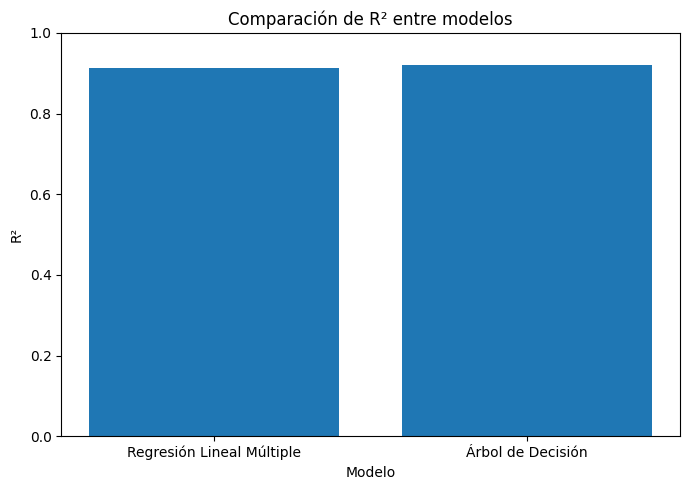

In [69]:
# Gráfico comparativo de R² entre modelos

plt.figure(figsize=(7, 5))

plt.bar(
    comparacion_modelos["Modelo"],
    comparacion_modelos["R²"]
)

plt.title("Comparación de R² entre modelos")
plt.xlabel("Modelo")
plt.ylabel("R²")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Conclusión final

En este proyecto se desarrollaron y compararon modelos de machine learning para predecir la variable `salary`, correspondiente al salario de una persona según distintas características laborales.

Primero se trabajó con un modelo de **Regresión Lineal Múltiple**, ya que la variable objetivo es numérica continua y se buscaba estimar un valor de salario. Este modelo permitió relacionar el salario con variables explicativas como años de experiencia, nivel educacional, certificaciones, cargo, industria, ubicación, modalidad de trabajo y tamaño de empresa. La regresión lineal obtuvo un buen desempeño, con un R² aproximado de 0,9123, lo que indica que logra explicar gran parte de la variabilidad del salario.

Luego se implementó un segundo modelo de **Árbol de Decisión para Regresión**. Este modelo también permite predecir una variable numérica, pero a diferencia de la regresión lineal, no asume una relación lineal entre las variables. El árbol divide los datos mediante condiciones o reglas, formando grupos con características similares para estimar el salario.

Para mejorar el modelo de árbol, se evaluaron distintas profundidades y se comparó el rendimiento en datos de entrenamiento y prueba. A partir de estos resultados, se seleccionó `max_depth=15`, ya que obtuvo el mejor desempeño dentro de las profundidades evaluadas y no presentó un sobreajuste fuerte. Además, se mantuvo `min_samples_leaf=20` para evitar que el árbol realizara predicciones basadas en grupos demasiado pequeños.

Al comparar ambos modelos, el **Árbol de Decisión para Regresión** obtuvo un desempeño levemente superior a la Regresión Lineal Múltiple. Esto se reflejó en un menor MAE, menor RMSE y un mayor R², alcanzando un R² aproximado de 0,9191. Esto significa que el árbol logró explicar una mayor proporción de la variabilidad del salario y presentó errores de predicción más bajos.

En conclusión, ambos modelos fueron adecuados para abordar el problema de predicción salarial, ya que lograron buenos resultados. Sin embargo, para este dataset, el Árbol de Decisión para Regresión fue el modelo con mejor rendimiento predictivo. Además, el análisis permitió identificar que variables como los años de experiencia, la ubicación, el tamaño de empresa y el nivel educacional tienen un rol relevante en la estimación del salario.

# Modelo Kmeans



En esta sección se implementa el algoritmo K-Means con el objetivo de segmentar los perfiles laborales del conjunto de datos. A diferencia de los modelos supervisados utilizados anteriormente, K-Means no busca predecir el salario, sino identificar grupos de trabajadores con características similares.

In [70]:
# Importar el algoritmo K-Means para realizar la segmentación de datos
from sklearn.cluster import KMeans

# Importar StandardScaler para escalar las variables numéricas
from sklearn.preprocessing import StandardScaler

### Selección de variables


Para realizar la segmentación se utilizarán variables numéricas relacionadas con el perfil profesional de cada trabajador. Estas variables fueron estandarizadas previamente durante la etapa de preprocesamiento, por lo que pueden utilizarse directamente para entrenar el modelo.

In [71]:
# Seleccionar las variables ya estandarizadas para entrenar K-Means

variables_cluster = df_escalado[
    [
        "experience_years",
        "skills_count",
        "certifications",
        "salary"
    ]
]

# Mostrar las primeras filas
display(variables_cluster.head())

,experience_years,skills_count,certifications,salary
0,-0.000892,-1.459647,-0.288272,-0.970520
1,-0.825894,1.277940,-1.460281,-1.388854
2,1.319111,-1.094636,-0.874276,0.064289
3,1.484112,0.547917,-1.460281,1.160315
4,0.824110,-0.547118,-1.460281,0.517295


# Método del Codo

El algoritmo K-Means requiere definir previamente la cantidad de clusters que se desean formar. Para seleccionar un número adecuado de grupos, se utiliza el **Método del Codo (Elbow Method)**.

Este método consiste en entrenar el modelo con diferentes cantidades de clusters y calcular la **inercia** para cada uno. La inercia mide qué tan cercanos están los datos al centro de su respectivo cluster; por lo tanto, valores menores indican una mejor agrupación.

Posteriormente, se grafica la inercia en función del número de clusters. El punto donde la disminución de la inercia comienza a estabilizarse, formando una figura similar a un "codo", se considera el número óptimo de clusters, ya que representa un equilibrio entre una buena segmentación y un modelo sin complejidad innecesaria.

In [72]:
# Crear una lista para almacenar la inercia de cada modelo
inercias = []

# Probar diferentes cantidades de clusters
for k in range(1, 11):

    # Crear el modelo K-Means con k clusters
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Entrenar el modelo con las variables seleccionadas
    modelo_kmeans.fit(variables_cluster)

    # Guardar la inercia obtenida
    inercias.append(modelo_kmeans.inertia_)

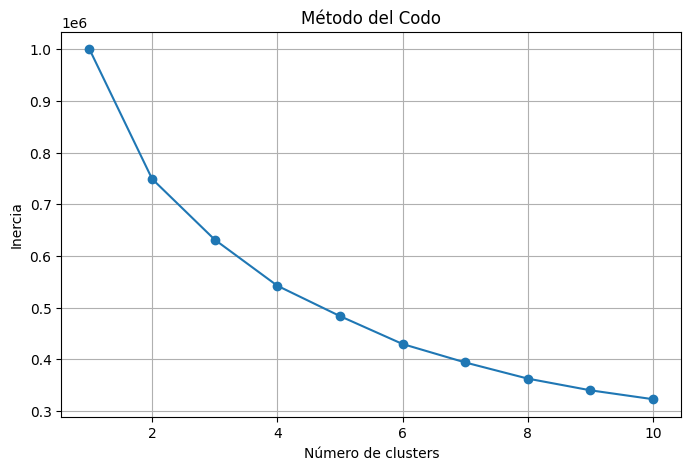

In [73]:
# Graficar el Método del Codo

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inercias,
    marker="o"
)

# Agregar título y nombres a los ejes
plt.title("Método del Codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

# Mostrar una cuadrícula para facilitar la interpretación
plt.grid(True)

# Mostrar el gráfico
plt.show()

### Interpretación del Método del Codo

Al analizar el gráfico del Método del Codo, se observa que la inercia disminuye considerablemente entre 1 y 4 clusters. A partir de este punto, la reducción de la inercia es mucho más gradual, indicando que aumentar la cantidad de clusters aporta una mejora cada vez menor en la calidad de la segmentación.

Por esta razón, se seleccionó **k = 4** como número óptimo de clusters, ya que representa un equilibrio adecuado entre la calidad de la agrupación y la simplicidad del modelo.

## Entrenamiento del modelo K-Means

Una vez determinado el número óptimo de clusters mediante el Método del Codo, se entrena el modelo K-Means utilizando **4 clusters**. Posteriormente, el algoritmo asigna cada trabajador a uno de los grupos identificados según las características seleccionadas.

In [74]:
# Crear el modelo K-Means utilizando 4 clusters
modelo_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Entrenar el modelo con las variables seleccionadas
modelo_kmeans.fit(variables_cluster)

# Asignar el cluster correspondiente a cada registro del dataset
df["cluster"] = modelo_kmeans.labels_

# Mostrar las primeras filas con el cluster asignado
display(
    df[
        [
            "experience_years",
            "skills_count",
            "certifications",
            "salary",
            "cluster"
        ]
    ].head()
)

,experience_years,skills_count,certifications,salary,cluster
0,10,2,2,109413,0
1,5,17,0,93764,1
2,18,4,1,148123,0
3,19,13,0,189123,3
4,15,7,0,165069,0


## Análisis de los clusters

Una vez entrenado el modelo, se analiza cada cluster calculando el promedio de las variables utilizadas en la segmentación. Esto permite identificar las características predominantes de cada grupo y comprender qué tipo de perfil profesional representa.

In [75]:
# Calcular el promedio de las variables para cada cluster
resumen_clusters = df.groupby("cluster")[
    [
        "experience_years",
        "skills_count",
        "certifications",
        "salary"
    ]
].mean().round(2)

# Mostrar el resumen de los clusters
display(resumen_clusters)

,experience_years,skills_count,certifications,salary
cluster,,,,
0,15.05,4.90,2.57,160141.87
1,5.68,9.85,0.89,121772.28
2,5.34,9.92,4.09,126212.09
3,14.43,15.03,2.52,176649.11


### Interpretación de los clusters

El análisis de los promedios permitió identificar diferencias claras entre los grupos generados por K-Means.

- **Cluster 0:** Agrupa profesionales con una amplia experiencia laboral y salarios elevados, aunque con una cantidad moderada de habilidades técnicas.

- **Cluster 1:** Representa trabajadores con menor experiencia, un buen número de habilidades técnicas y pocas certificaciones, asociados a salarios intermedios.

- **Cluster 2:** Corresponde a profesionales con poca experiencia, pero con una mayor cantidad de certificaciones, lo que se refleja en un salario ligeramente superior al del cluster 1.

- **Cluster 3:** Reúne a los profesionales con mayor experiencia, mayor cantidad de habilidades técnicas y los salarios promedio más altos, representando perfiles de mayor desarrollo profesional.

## Visualización de los clusters

Para facilitar la interpretación de los resultados, se representa gráficamente la distribución de los clusters utilizando los años de experiencia y el salario. Esto permite observar cómo el algoritmo segmentó los perfiles laborales según estas dos variables.

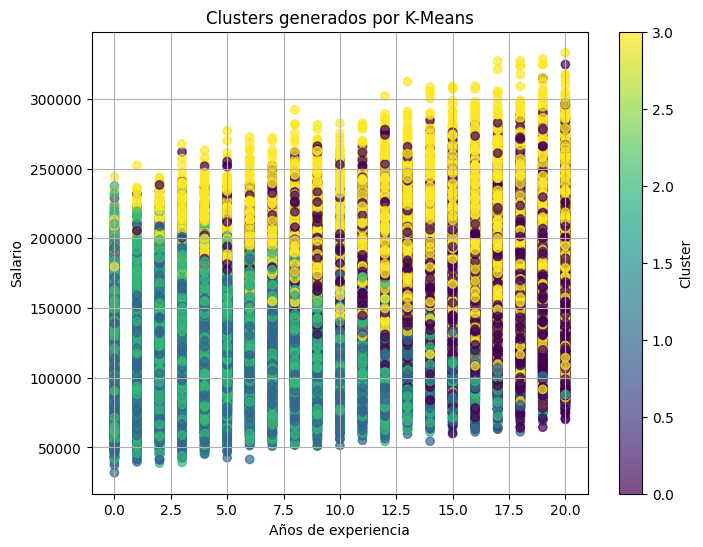

In [76]:
# Crear una figura para visualizar los clusters
plt.figure(figsize=(8,6))

# Graficar los registros utilizando experiencia y salario
plt.scatter(
    df["experience_years"],
    df["salary"],
    c=df["cluster"],      # Color según el cluster asignado
    cmap="viridis",       # Paleta de colores
    alpha=0.7             # Transparencia de los puntos
)

# Agregar título y etiquetas
plt.title("Clusters generados por K-Means")
plt.xlabel("Años de experiencia")
plt.ylabel("Salario")

# Agregar una barra de colores para identificar los clusters
plt.colorbar(label="Cluster")

# Mostrar una cuadrícula
plt.grid(True)

# Mostrar el gráfico
plt.show()

### Interpretación de la visualización

La gráfica muestra la distribución de los trabajadores según sus años de experiencia y salario, diferenciando cada registro por el cluster asignado por el algoritmo K-Means.

Se observa una tendencia general donde los salarios aumentan conforme crece la experiencia laboral. Sin embargo, también existe superposición entre algunos clusters. Esto ocurre porque el algoritmo no solo considera la experiencia y el salario para realizar la segmentación, sino también variables como la cantidad de habilidades y certificaciones. Por esta razón, trabajadores con valores similares en el gráfico pueden pertenecer a clusters diferentes debido a diferencias en otras características consideradas por el modelo.

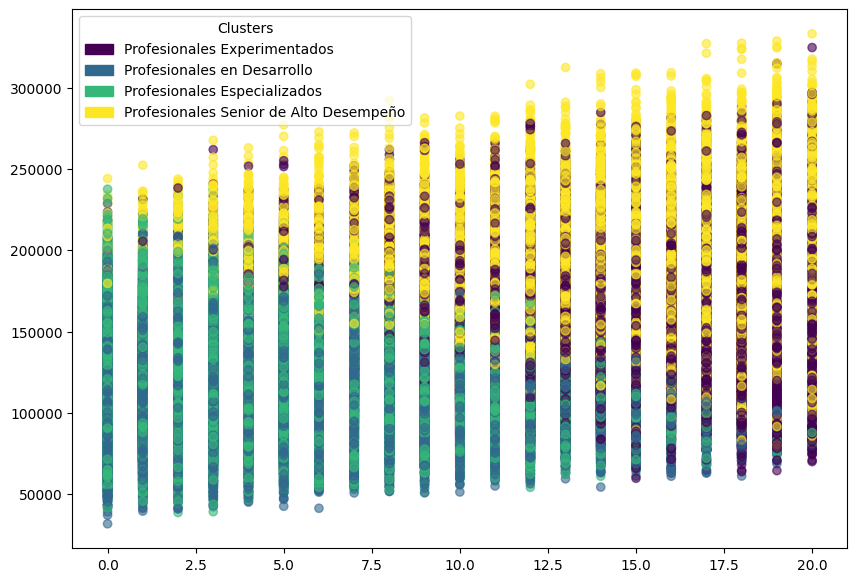

In [109]:
import matplotlib.patches as mpatches

# Crear la figura
plt.figure(figsize=(10,7))

# Graficar los puntos
scatter = plt.scatter(
    df["experience_years"],
    df["salary"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.6
)

# Crear leyenda personalizada
leyenda = [
    mpatches.Patch(color=scatter.cmap(scatter.norm(0)), label="Profesionales Experimentados"),
    mpatches.Patch(color=scatter.cmap(scatter.norm(1)), label="Profesionales en Desarrollo"),
    mpatches.Patch(color=scatter.cmap(scatter.norm(2)), label="Profesionales Especializados"),
    mpatches.Patch(color=scatter.cmap(scatter.norm(3)), label="Profesionales Senior de Alto Desempeño")
]

plt.legend(handles=leyenda, title="Clusters")

| **Cluster** | **Perfil identificado**                | **Características principales**                                                       |
| :---------: | -------------------------------------- | ------------------------------------------------------------------------------------- |
|    **0**    | Profesionales Experimentados           | Alta experiencia, salarios elevados y habilidades moderadas.                          |
|    **1**    | Profesionales en Desarrollo            | Menor experiencia, buenas habilidades, pocas certificaciones y salario intermedio.    |
|    **2**    | Profesionales Especializados           | Poca experiencia, muchas certificaciones y salario ligeramente superior al Cluster 1. |
|    **3**    | Profesionales Senior de Alto Desempeño | Mayor experiencia, más habilidades técnicas y el salario promedio más alto.           |


## Conclusiones del modelo K-Means

El algoritmo K-Means permitió segmentar el conjunto de datos en cuatro grupos de trabajadores con características similares, considerando variables como los años de experiencia, la cantidad de habilidades, las certificaciones y el salario.

Los resultados muestran que existen perfiles profesionales claramente diferenciados. Algunos grupos concentran trabajadores con mayor experiencia y salarios más altos, mientras que otros agrupan profesionales con menor experiencia, pero con diferentes niveles de habilidades y certificaciones.

Esta segmentación complementa el análisis realizado mediante los modelos supervisados, ya que permite identificar patrones dentro de los datos sin necesidad de predecir una variable objetivo. Además, los clusters obtenidos pueden servir como apoyo para la toma de decisiones, facilitando la identificación de distintos perfiles laborales dentro del mercado analizado.

# Set de datos de prueba

En esta sección se crea un conjunto de datos de prueba con perfiles laborales nuevos. Estos registros no corresponden directamente a filas del dataset original, sino que se construyen manualmente para simular posibles casos reales.

El objetivo es comprobar que el modelo entrenado puede recibir nuevos datos de entrada y generar una estimación de salario a partir de las características del perfil profesional.

In [78]:
# Crear un conjunto de datos de prueba con nuevos perfiles laborales

datos_prueba = pd.DataFrame([
    {
        "job_title": "Data Scientist",
        "experience_years": 5,
        "education_level": "Bachelor",
        "skills_count": 8,
        "certifications": 2,
        "company_size": "Medium",
        "industry": "Technology",
        "location": "Canada",
        "remote_work": "Hybrid"
    },
    {
        "job_title": "AI Engineer",
        "experience_years": 12,
        "education_level": "Master",
        "skills_count": 15,
        "certifications": 3,
        "company_size": "Enterprise",
        "industry": "Technology",
        "location": "UK",
        "remote_work": "Yes"
    },
    {
        "job_title": "Data Analyst",
        "experience_years": 2,
        "education_level": "Diploma",
        "skills_count": 6,
        "certifications": 1,
        "company_size": "Small",
        "industry": "Finance",
        "location": "India",
        "remote_work": "No"
    }
])

# Mostrar los perfiles creados
display(datos_prueba)

,job_title,experience_years,education_level,skills_count,certifications,company_size,industry,location,remote_work
0,Data Scientist,5,Bachelor,8,2,Medium,Technology,Canada,Hybrid
1,AI Engineer,12,Master,15,3,Enterprise,Technology,UK,Yes
2,Data Analyst,2,Diploma,6,1,Small,Finance,India,No


In [79]:
# Crear una lista para guardar las predicciones del modelo
predicciones_prueba = []

# Recorrer cada perfil del conjunto de datos de prueba
for i, fila in datos_prueba.iterrows():

    # Realizar la predicción de salario usando el modelo de Árbol de Decisión
    salario_estimado = predecir_salario_arbol(
        job_title=fila["job_title"],
        experience_years=fila["experience_years"],
        education_level=fila["education_level"],
        skills_count=fila["skills_count"],
        certifications=fila["certifications"],
        company_size=fila["company_size"],
        industry=fila["industry"],
        location=fila["location"],
        remote_work=fila["remote_work"]
    )

    # Guardar la predicción en la lista
    predicciones_prueba.append(salario_estimado)

# Agregar las predicciones como una nueva columna en el DataFrame
datos_prueba["salario_estimado_arbol"] = predicciones_prueba

# Redondear el salario estimado para facilitar la lectura
datos_prueba["salario_estimado_arbol"] = datos_prueba["salario_estimado_arbol"].round(0).astype(int)

# Mostrar los perfiles junto con el salario estimado
display(datos_prueba)

,job_title,experience_years,education_level,skills_count,certifications,company_size,industry,location,remote_work,salario_estimado_arbol
0,Data Scientist,5,Bachelor,8,2,Medium,Technology,Canada,Hybrid,142449
1,AI Engineer,12,Master,15,3,Enterprise,Technology,UK,Yes,247907
2,Data Analyst,2,Diploma,6,1,Small,Finance,India,No,53210


### Interpretación del set de datos de prueba

El modelo de Árbol de Decisión generó predicciones salariales para tres perfiles laborales nuevos. Los resultados son coherentes con las características ingresadas, ya que el perfil de AI Engineer obtuvo el salario estimado más alto debido a su mayor experiencia, mayor cantidad de habilidades, nivel educacional avanzado y pertenencia a una empresa de mayor tamaño.

Por otro lado, el perfil de Data Analyst obtuvo el salario estimado más bajo, lo que se relaciona con su menor experiencia laboral, menor cantidad de habilidades y características laborales menos favorables dentro del conjunto de datos analizado.

Este resultado demuestra que el modelo puede aplicarse sobre nuevos registros y no solamente sobre los datos originales utilizados durante el entrenamiento.

# Exportación del dataset para dashboard

En esta sección se exporta el dataset final en formato CSV para utilizarlo en una herramienta de visualización como Looker Studio o Power BI. Este archivo permitirá construir un panel con gráficos e indicadores que apoyen la interpretación de los resultados obtenidos en el análisis.

In [80]:
# Exportar el dataset final para utilizarlo en Looker Studio o Power BI

df.to_csv("dataset_salarios_dashboard.csv", index=False)

print("Archivo exportado correctamente: dataset_salarios_dashboard.csv")

# Descargar automáticamente el archivo CSV desde Colab

from google.colab import files

files.download("dataset_salarios_dashboard.csv")

Archivo exportado correctamente: dataset_salarios_dashboard.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
# Crear un botón para abrir Looker Studio desde Colab

from IPython.display import HTML

HTML("""
<a href="https://lookerstudio.google.com/" target="_blank">
    <button style="
        background-color:#1a73e8;
        color:white;
        padding:10px 18px;
        border:none;
        border-radius:6px;
        font-size:16px;
        cursor:pointer;">
        Abrir Looker Studio
    </button>
</a>
""")

## Exportación y acceso al dashboard

Para facilitar la construcción del dashboard, se exportó el dataset final en formato CSV. Este archivo puede ser cargado posteriormente en Looker Studio o Power BI para crear visualizaciones interactivas.

Además, se agregó un acceso directo desde Google Colab hacia la herramienta de visualización seleccionada, permitiendo continuar el flujo de trabajo de forma más ordenada.

Link Looker Studio

https://datastudio.google.com/reporting/1144ebb3-de87-43b7-ac47-ca52d630f9e4

# Web Scraping con Selenium

En esta sección se utiliza Selenium para extraer información desde una página web de ofertas laborales. El objetivo es complementar el análisis del dataset original con información externa relacionada con cargos tecnológicos, empresas, ubicación y habilidades solicitadas en el mercado laboral.

Selenium permite automatizar la navegación en una página web, esperar la carga de contenido dinámico y extraer información visible desde el navegador.

In [86]:
# Instalar librería para usar Selenium en Google Colab
!pip install -q google-colab-selenium

In [87]:
# Importar librerías necesarias
import google_colab_selenium as gs
from selenium.webdriver.common.by import By
import pandas as pd
import time

# Iniciar navegador Chrome configurado para Google Colab
driver = gs.Chrome()

print("Selenium iniciado correctamente.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Selenium iniciado correctamente.


In [93]:
# Abrir página con información de ingresos promedio por país

url_ingresos = "https://www.worlddata.info/average-income.php"

driver.get(url_ingresos)

# Esperar unos segundos para que cargue la página
time.sleep(5)

# Verificar que la página cargó correctamente
print("Título de la página:", driver.title)

Título de la página: Average income around the world


### Extracción de tabla mediante Selenium

Después de cargar la página web con Selenium, se utilizó `pd.read_html()` para extraer automáticamente las tablas HTML disponibles en el contenido de la página.

El resultado muestra que se encontró **1 tabla**, con **106 filas y 3 columnas**. Esta tabla contiene información relacionada con ingresos promedio por país, incluyendo:

- `Country/Region`: país o región.
- `Ø Annual income`: ingreso anual promedio.
- `Ø Gross annual wage`: salario bruto anual promedio.

Para este análisis se utilizará principalmente la columna `Ø Annual income`, ya que contiene información más completa para los países disponibles. Esta variable permitirá complementar el dataset original con una referencia económica externa asociada a la ubicación geográfica de cada registro.

Esta etapa forma parte del proceso de Web Scraping, ya que la información fue obtenida desde una página web externa utilizando Selenium para cargar la página y luego extraer su contenido estructurado.

In [104]:
# Extraer todas las tablas HTML desde la página cargada con Selenium

tablas_ingresos = pd.read_html(driver.page_source)

# Mostrar cuántas tablas fueron encontradas
print("Cantidad de tablas encontradas:", len(tablas_ingresos))

# Revisar las primeras tablas encontradas
for i, tabla in enumerate(tablas_ingresos[:3]):
    print("Tabla:", i)
    print("Dimensiones:", tabla.shape)
    display(tabla.head())

Cantidad de tablas encontradas: 1
Tabla: 0
Dimensiones: (106, 3)


/tmp/ipykernel_5315/2658446099.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tablas_ingresos = pd.read_html(driver.page_source)


,Country/Region,Ø Annual income,Ø Gross annual wage
0,Monaco,"186,080 $",NaN
1,Bermuda *,"145,150 $",NaN
2,Liechtenstein,"116,440 $",NaN
3,Norway,"98,170 $","66,943 $"
4,Switzerland,"95,220 $","110,022 $"


### Resultado del Web Scraping

La página cargada con Selenium contiene una tabla con información de ingresos promedio por país. Mediante `pd.read_html()` se extrajo automáticamente esa tabla, obteniendo 106 registros y 3 columnas.

Esta información será utilizada para aumentar el dataset original, agregando una referencia económica por país. De esta manera, los salarios del dataset podrán compararse con el ingreso anual promedio del país correspondiente.

In [107]:
# Seleccionar la primera tabla encontrada mediante Selenium
# Como solo se encontró una tabla, se usa el índice [0]

tabla_ingresos = tablas_ingresos[0]

# Mostrar las primeras filas para verificar que la tabla fue seleccionada correctamente
display(tabla_ingresos.head())

,Country/Region,Ø Annual income,Ø Gross annual wage
0,Monaco,"186,080 $",NaN
1,Bermuda *,"145,150 $",NaN
2,Liechtenstein,"116,440 $",NaN
3,Norway,"98,170 $","66,943 $"
4,Switzerland,"95,220 $","110,022 $"


In [105]:
# Crear una copia de la tabla extraída mediante Selenium
df_ingresos_paises = tabla_ingresos.copy()

# Renombrar las columnas para trabajar con nombres más simples
df_ingresos_paises = df_ingresos_paises.rename(columns={
    "Country/Region": "country",
    "Ø Annual income": "annual_income_usd",
    "Ø Gross annual wage": "gross_annual_wage_usd"
})

# Limpiar el nombre de los países
df_ingresos_paises["country"] = (
    df_ingresos_paises["country"]
    .astype(str)
    .str.replace("*", "", regex=False)
    .str.strip()
)

# Limpiar la columna de ingreso anual:
# se eliminan símbolos, comas y espacios para dejar solo el valor numérico
df_ingresos_paises["annual_income_usd"] = (
    df_ingresos_paises["annual_income_usd"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

# Seleccionar solo las columnas necesarias para aumentar el dataset
df_ingresos_paises = df_ingresos_paises[
    [
        "country",
        "annual_income_usd"
    ]
]

# Mostrar la tabla limpia
display(df_ingresos_paises.head())

,country,annual_income_usd
0,Monaco,186080.0
1,Bermuda,145150.0
2,Liechtenstein,116440.0
3,Norway,98170.0
4,Switzerland,95220.0


La tabla resultante muestra los países junto con su ingreso anual promedio expresado en dólares. Esta información será utilizada como una variable externa para complementar el análisis salarial del dataset principal.

In [98]:
# Diccionario para homologar los nombres de países del dataset original
# con los nombres encontrados en la tabla obtenida mediante scraping

mapeo_paises = {
    "USA": "United States",
    "UK": "United Kingdom",
    "Canada": "Canada",
    "Germany": "Germany",
    "Sweden": "Sweden",
    "Australia": "Australia",
    "Singapore": "Singapore",
    "Netherlands": "Netherlands",
    "India": "India"
}

# Crear una lista con los países que existen en el dataset y que se buscarán en la tabla externa
paises_relevantes = list(mapeo_paises.values())

# Filtrar la tabla obtenida por Selenium para conservar solo los países relacionados con el dataset
df_ingresos_relevantes = df_ingresos_paises[
    df_ingresos_paises["country"].isin(paises_relevantes)
].copy()

# Mostrar los países relevantes encontrados
display(df_ingresos_relevantes)

,country,annual_income_usd
6,United States,83490.0
12,Singapore,74750.0
16,Australia,62680.0
17,Netherlands,62520.0
18,Sweden,58190.0
21,Germany,55090.0
23,Canada,53400.0
26,United Kingdom,49470.0
90,India,2650.0


La tabla resultante muestra únicamente los países relevantes para el dataset original junto con su ingreso anual promedio. Esto permite integrar la información externa de forma más ordenada y evitar países que no serán utilizados en el análisis.

In [99]:
# Crear una copia del dataset original para aumentar datos
df_aumentado = df.copy()

# Excluir registros cuya ubicación sea Remote, porque no corresponde a un país específico
df_aumentado = df_aumentado[df_aumentado["location"] != "Remote"].copy()

# Crear una columna auxiliar con el nombre del país homologado
df_aumentado["country_scraping"] = df_aumentado["location"].map(mapeo_paises)

# Verificar si quedó alguna ubicación sin homologar
print("Ubicaciones sin homologar:", df_aumentado["country_scraping"].isnull().sum())

# Unir el dataset original con la información obtenida mediante Web Scraping
df_aumentado = df_aumentado.merge(
    df_ingresos_relevantes,
    left_on="country_scraping",
    right_on="country",
    how="left"
)

# Verificar si quedaron valores nulos después de la unión
print("Valores nulos en annual_income_usd:", df_aumentado["annual_income_usd"].isnull().sum())

# Mostrar algunas filas del dataset aumentado
display(
    df_aumentado[
        [
            "location",
            "country_scraping",
            "salary",
            "annual_income_usd"
        ]
    ].head()
)

Ubicaciones sin homologar: 0
Valores nulos en annual_income_usd: 0


,location,country_scraping,salary,annual_income_usd
0,India,India,109413,2650.0
1,Australia,Australia,93764,62680.0
2,Singapore,Singapore,148123,74750.0
3,Canada,Canada,189123,53400.0
4,Sweden,Sweden,165069,58190.0


La tabla muestra una vista del dataset aumentado. Ahora, además del salario original de cada registro, se incorpora el ingreso anual promedio del país correspondiente. Esta nueva información permite contextualizar los salarios del dataset según la ubicación geográfica.

In [100]:
# Crear una nueva variable para comparar el salario del dataset
# con el ingreso anual promedio del país obtenido mediante scraping

df_aumentado["salary_vs_country_income"] = (
    df_aumentado["salary"] / df_aumentado["annual_income_usd"]
)

# Mostrar el resultado de la nueva variable
display(
    df_aumentado[
        [
            "location",
            "salary",
            "annual_income_usd",
            "salary_vs_country_income"
        ]
    ].head()
)

,location,salary,annual_income_usd,salary_vs_country_income
0,India,109413,2650.0,41.287925
1,Australia,93764,62680.0,1.495916
2,Singapore,148123,74750.0,1.981579
3,Canada,189123,53400.0,3.541629
4,Sweden,165069,58190.0,2.836725


### Creación de variable comparativa

En esta etapa se crea la variable `salary_vs_country_income`, que permite comparar el salario de cada registro del dataset con el ingreso anual promedio del país obtenido mediante Web Scraping.

La variable se calcula dividiendo el salario del registro (`salary`) por el ingreso anual promedio del país (`annual_income_usd`).

Por ejemplo, si un registro tiene un valor de `salary_vs_country_income` igual a 2, significa que su salario es aproximadamente el doble del ingreso anual promedio del país correspondiente.

Esta nueva variable permite contextualizar mejor los salarios, ya que no solo se observa el valor absoluto del sueldo, sino también qué tan alto o bajo es en relación con la realidad económica del país.

In [101]:
# Comparar dimensiones del dataset original y del dataset aumentado

print("Dimensiones del dataset original:", df.shape)
print("Dimensiones del dataset aumentado:", df_aumentado.shape)

print("Columnas agregadas por scraping:")
print(["country_scraping", "country", "annual_income_usd", "salary_vs_country_income"])

Dimensiones del dataset original: (250000, 11)
Dimensiones del dataset aumentado: (224935, 15)
Columnas agregadas por scraping:
['country_scraping', 'country', 'annual_income_usd', 'salary_vs_country_income']


In [102]:
# Exportar el dataset aumentado con la información obtenida mediante Web Scraping

df_aumentado.to_csv("dataset_salarios_aumentado_scraping.csv", index=False)

print("Archivo exportado correctamente: dataset_salarios_aumentado_scraping.csv")

Archivo exportado correctamente: dataset_salarios_aumentado_scraping.csv


In [103]:
# Mostrar las primeras filas del dataset aumentado
display(df_aumentado.head())

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,cluster,country_scraping,country,annual_income_usd,salary_vs_country_income
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,0,India,India,2650.0,41.287925
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,1,Australia,Australia,62680.0,1.495916
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,0,Singapore,Singapore,74750.0,1.981579
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,3,Canada,Canada,53400.0,3.541629
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,0,Sweden,Sweden,58190.0,2.836725


### Conclusión del Web Scraping con Selenium

El uso de Selenium permitió extraer información externa sobre ingresos anuales promedio por país. Estos datos fueron limpiados e integrados al dataset original mediante la variable `location`, excluyendo los registros con ubicación `Remote` para evitar inconsistencias.

Como resultado, se incorporó la variable `annual_income_usd` y se creó `salary_vs_country_income`, que permite comparar cada salario con el ingreso promedio del país correspondiente.

En conclusión, el Web Scraping permitió aumentar el dataset y aportar una referencia externa para contextualizar mejor los salarios según la ubicación geográfica.